In [1]:
import os
import torch
import sys
import numpy as np
import pandas as pd
sys.path.append(os.path.abspath("utils"))

import importlib
import quant_concept_evals_utils
importlib.reload(quant_concept_evals_utils)

from quant_concept_evals_utils import compute_concept_metrics
from general_utils import get_split_df

# Plot Metrics

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_concept_metrics(metric_dfs, metric_name, title, xmin=None, xmax=None):
    """
    Plots a horizontal bar chart comparing a chosen metric across multiple metrics DataFrames.

    Args:
        metric_dfs (dict): Dictionary mapping labels (str) to pd.DataFrame of concept metrics.
        metric_name (str): The metric to plot (e.g., 'accuracy', 'f1').
        title (str): Title of the plot.

    Returns:
        None (Displays the plot).
    """
    labels = list(metric_dfs.keys())  # Extract labels
    metric_dfs = list(metric_dfs.values())  # Extract corresponding DataFrames

    colors = sns.color_palette("husl", len(metric_dfs))  # Generate distinct colors
    
    # Extract all unique concepts from the first DataFrame (assume all have the same concepts)
    concepts = metric_dfs[0]["concept"].tolist()
    
    # Increase spacing by modifying the y positions
    spacing = 0.3  # Adjust spacing factor
    y = np.arange(len(concepts)) * (len(metric_dfs) * 0.2 + spacing)  # Space out concepts
    
    # Create a figure and axis
    fig, ax = plt.subplots(figsize=(10, 20))
    
    # Bar width
    bar_width = 0.2

    # Plot each metric_df's values
    for i, (label, df, color) in enumerate(zip(labels, metric_dfs, colors)):
        values = df.set_index("concept")[metric_name].reindex(concepts).values
        ax.barh(y + i * bar_width, values, height=bar_width, label=label, color=color)
    
    # Formatting
    ax.set_yticks(y + (len(metric_dfs) - 1) * bar_width / 2)
    ax.set_yticklabels(concepts)
    ax.set_xlabel(metric_name.capitalize())
    ax.set_title(title)
    
    if xmin is not None and xmax is not None:
        ax.set_xlim(xmin, xmax)
    
    # Move legend outside the plot
    ax.legend(title="Source", loc="upper left", bbox_to_anchor=(1, 1))
    
    # Show the plot
    plt.tight_layout()
    plt.show()

    

def plot_average_metrics(metric_dfs, metric_name, title=None, xmin=None, xmax=None):
    """
    Plots a horizontal bar chart comparing average metrics across multiple methods.

    Args:
        metric_dfs (dict): Mapping from label -> pd.DataFrame (with 'concept' and metric_name columns).
        metric_name (str): Metric to plot ('f1', 'accuracy', etc).
        title (str, optional): Title for the plot.
        xmin (float, optional): Minimum x-axis value.
        xmax (float, optional): Maximum x-axis value.
    """
    labels = list(metric_dfs.keys())
    avg_metrics = [df[metric_name].mean() for df in metric_dfs.values()]

    fig, ax = plt.subplots(figsize=(8, len(labels) * 0.7))

    colors = sns.color_palette("husl", len(labels))
    bars = ax.barh(labels, avg_metrics, color=colors)

    # Add text annotations at the end of each bar
    for bar, value in zip(bars, avg_metrics):
        ax.text(
            bar.get_width() + 0.01,  # slightly offset from the end of bar
            bar.get_y() + bar.get_height() / 2,
            f"{value:.2f}",
            va='center',
            ha='left',
            fontsize=10,
            fontweight='bold'
        )

    ax.set_xlabel(metric_name.capitalize())
    ax.set_ylabel("Concept Discovery Method")
    if title:
        ax.set_title(title)

    if xmin is not None or xmax is not None:
        ax.set_xlim(left=xmin if xmin is not None else 0,
                    right=xmax if xmax is not None else 1)

    plt.grid(axis='x', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()
    

def plot_grouped_metrics(data_dict, baseline_dfs, metric, baseline_type, curr_concepts=None, title=None, xmin=0, xmax=1):
    """
    Plots a horizontal grouped bar chart for a chosen metric for each concept,
    for each model and scheme.

    Args:
        data_dict (dict): Nested dictionary of {model: {scheme: DataFrame}}.
        metric (str): The name of the metric column to plot.
        title (str, optional): The plot title.
        xmin (float, optional): Minimum x-axis value.
        xmax (float, optional): Maximum x-axis value.
    """
    models = list(data_dict.keys())
    # Get the set of concepts for each model (assume all scheme dfs have the same concepts)
    model_concepts = {}
    for model in models:
        schemes = list(data_dict[model].keys())
        if schemes:
            df = data_dict[model][schemes[0]]
            if curr_concepts is not None:
                model_concepts[model] = [concept for concept in df['concept'].unique() if concept in curr_concepts]
            else:
                model_concepts[model] = df['concept'].unique().tolist()
        else:
            model_concepts[model] = []
    
    # Gather all schemes across models and create color mapping
    all_schemes = [scheme for scheme in data_dict[models[0]].keys()]
    cmap = plt.get_cmap("tab10")
    scheme_colors = {scheme: cmap(i) for i, scheme in enumerate(all_schemes)}
    baseline_colors = {model: cmap(i+len(all_schemes)) for i, model in enumerate(models)}

    # Determine vertical positions
    y_positions = {}  # mapping (model, concept) -> y coordinate
    model_centers = {}  # mapping model -> vertical center (for model label)
    current_y = 0
    model_gap = 0.7  # gap between models

    for model in models:
        concepts = model_concepts[model]
        for concept in concepts:
            y_positions[(model, concept)] = current_y
            current_y += 1
        model_centers[model] = np.mean([y_positions[(model, c)] for c in concepts]) if concepts else current_y
        current_y += model_gap  # add gap after each model

    # Plotting setup
    fig, ax = plt.subplots(figsize=(15, 10))

    # Plot bars for each (model, concept)
    for model in models:
        baseline_model_df = baseline_dfs[model]
        for concept in model_concepts[model]:
                
            applicable_schemes = []
            values = {}

            # Collect metric values for each scheme
            for scheme in all_schemes:
                if scheme in data_dict[model]:
                    df = data_dict[model][scheme]
                    row = df[df['concept'] == concept]
                    if not row.empty:
                        values[scheme] = row.iloc[0][metric]
                        applicable_schemes.append(scheme)

            if not applicable_schemes:
                continue

            # Bar height calculation and placement
            bar_height = 0.6 / len(applicable_schemes)
            center_y = y_positions[(model, concept)]
            for i, scheme in enumerate(applicable_schemes):
                offset = (i - (len(applicable_schemes) - 1) / 2) * bar_height
                ax.barh(center_y + offset, values[scheme], height=bar_height, color=scheme_colors[scheme],
                        label=scheme if (model == models[0] and concept == model_concepts[model][0]) else None)
                
            offset = (len(applicable_schemes) - (len(applicable_schemes) - 1) / 2) * bar_height
            baseline_val = baseline_model_df[baseline_model_df['concept'] == concept].iloc[0][metric]
            ax.barh(center_y + offset, baseline_val, height=bar_height, color=baseline_colors[model], label=f"{model} {baseline_type}")

            # Align concept labels with the center of the bars
            # Get the position for the middle of the bars for this concept
            bar_positions = []
            for i, scheme in enumerate(applicable_schemes):
                bar_positions.append(center_y + (i - (len(applicable_schemes) - 1) / 2) * bar_height)

            # The position of the concept label is aligned with the center of the bars
            concept_label_x = xmin - 0.01 * (xmax - xmin)
            concept_label_y = np.mean(bar_positions)  # The average position of all the bars for this concept
            ax.text(concept_label_x, concept_label_y, concept, va='center', ha='right', fontsize=10)

    # Remove y-ticks
    ax.set_yticks([])

    ax.set_xlabel(metric, fontsize=12)
    if title:
        ax.set_title(title, fontsize=14)

    # Position model labels
    current_xlim = ax.get_xlim()
    model_label_x = xmin - 0.1 * (xmax - xmin)
    for model in models:
        ax.text(model_label_x, model_centers[model], model, va='center', ha='right', fontsize=12, fontweight='bold')

    # Create legend
     # Retrieve the handles and labels created by the plotting calls.
    handles, labels = ax.get_legend_handles_labels()
    
    # Separate sub-label entries from baseline entries.
    sub_label_handles = []
    sub_label_labels = []
    baseline_handles = []
    baseline_labels = []
    
    for h, l in zip(handles, labels):
        # We assume baseline entries contain the baseline_type string.
        if baseline_type in l:
            if l not in baseline_labels:
                baseline_handles.append(h)
                baseline_labels.append(l)
        else:
            if l not in sub_label_labels:
                sub_label_handles.append(h)
                sub_label_labels.append(l)
    
    # Reverse the order of sub-label entries and baseline entries individually.
    sub_label_handles = list(sub_label_handles)[::-1]
    sub_label_labels = list(sub_label_labels)[::-1]
    baseline_handles = list(baseline_handles)[::-1]
    baseline_labels = list(baseline_labels)[::-1]
    
    # Combine: first the reversed sub-labels, then the reversed baseline entries.
    ordered_handles = baseline_handles + sub_label_handles
    ordered_labels = baseline_labels + sub_label_labels 
    
    # Create the legend with the reordered entries.
    ax.legend(ordered_handles, ordered_labels, title="Legend",
              bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    

    plt.show()



def plot_average_grouped_metrics(data_dict, baseline_dfs, metric, baseline_type, title=None, xmin=None, xmax=None):
    """
    Plots a horizontal grouped bar chart for a chosen metric averaged across concepts,
    including baseline values computed from a dictionary of baseline dataframes.

    Args:
        data_dict (dict): A dictionary where keys are overall labels and values are dictionaries.
                          The inner dictionary has sub-labels as keys and dataframes as values.
                          Each dataframe must have a column corresponding to the chosen metric.
        baseline_dfs (dict): A dictionary mapping each overall label to a dataframe.
                             Each dataframe must have a column corresponding to the chosen metric.
        metric (str): The column name for which the average is computed.
        title (str, optional): The title of the plot.
        xmin (float, optional): Minimum x-axis value.
        xmax (float, optional): Maximum x-axis value.
    """
    # Get overall labels and assume that each inner dict has the same sub-labels
    # overall_labels = list(data_dict.keys())[::-1]
    overall_labels = list(data_dict.keys())
    sub_labels = list(next(iter(data_dict.values())).keys())
    
    # Compute the average of the chosen metric for each (overall, sub) pair from data_dict
    averages = {
        ov_label: {
            sub_label: df[metric].mean() 
            for sub_label, df in sub_dict.items()
        } 
        for ov_label, sub_dict in data_dict.items()
    }
    
    # Compute baseline average metric values over concepts for each overall label.
    baseline_values = {
        ov_label: baseline_dfs[ov_label][metric].mean() 
        for ov_label in overall_labels if ov_label in baseline_dfs
    }
    
    # Set up plotting parameters for grouped horizontal bars.
    n_groups = len(overall_labels)
    n_sub = len(sub_labels)
    # Allocate space for sub-label bars and one extra for baseline within each group.
    bar_height = 0.8 / (n_sub + 1)
    
    # Create a color map for the sub-labels.
    cmap = plt.get_cmap("tab10")
    colors = {sub_label: cmap(i) for i, sub_label in enumerate(sub_labels)}
    baseline_colors = {ov_label: cmap(i+len(sub_labels)) for i, ov_label in enumerate(overall_labels)}
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Determine y positions for each overall group.
    y_group_positions = np.arange(n_groups)
    
    # Plot bars for each overall label.
    for i, ov_label in enumerate(overall_labels):
        group_center = y_group_positions[i]
        start_y = group_center - 0.2  # Center the group vertically around the integer position.
        
        # Plot bars for each sub-label
        for j, sub_label in enumerate(sub_labels):
            if sub_label in data_dict[ov_label].keys():
                y = start_y + j * bar_height
                value = averages[ov_label][sub_label]
                ax.barh(y, value, height=bar_height, color=colors[sub_label],
                        label=sub_label if i == 0 else None)
                           
        # Plot baseline bar (placed as the last bar in the group)
        baseline_y = start_y + n_sub * bar_height
        baseline_val = baseline_values.get(ov_label, 0)
        ax.barh(baseline_y, baseline_val, height=bar_height,
                alpha=0.6, color=baseline_colors[ov_label], label=f'{ov_label} {baseline_type}')
    
    # Set y-axis ticks to show overall labels (center of each group)
    ax.set_yticks(y_group_positions)
    ax.set_yticklabels(overall_labels, fontsize=12)
    
    if xmin is not None and xmax is not None:
        ax.set_xlim(xmin, xmax)
    
    ax.set_xlabel(metric, fontsize=12)
    
    if title:
        ax.set_title(title, fontsize=14)
    
     # Retrieve the handles and labels created by the plotting calls.
    handles, labels = ax.get_legend_handles_labels()
    
    # Separate sub-label entries from baseline entries.
    sub_label_handles = set()
    sub_label_labels = set()
    baseline_handles = set()
    baseline_labels = set()
    
    for h, l in zip(handles, labels):
        # We assume baseline entries contain the baseline_type string.
        if baseline_type in l:
            baseline_handles.add(h)
            baseline_labels.add(l)
        else:
            sub_label_handles.add(h)
            sub_label_labels.add(l)
    
    # Reverse the order of sub-label entries and baseline entries individually.
    sub_label_handles = list(sub_label_handles)[::-1]
    sub_label_labels = list(sub_label_labels)[::-1]
    baseline_handles = list(baseline_handles)[::-1]
    baseline_labels = list(baseline_labels)[::-1]
    
    # Combine: first the reversed sub-labels, then the reversed baseline entries.
    ordered_handles = baseline_handles + sub_label_handles
    ordered_labels = baseline_labels + sub_label_labels 
    
    # Create the legend with the reordered entries.
    ax.legend(ordered_handles, ordered_labels, title="Legend",
              bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    
    plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust layout to leave space for the legend
    plt.show()

## Compare to Baselines

In [56]:
def compare_to_baseline(metric_type, primary_scheme, dataset_name, model_name, sample_type, justobj=False, plot_average=True):
    dir = f'Quant_Results/{dataset_name}'
    
    baseline_path = f'{model_name}_{sample_type}_baseline.csv'
    if sample_type == 'patch' and justobj:
        baseline_path = f'justobj_{baseline_path}'
    baseline1_df = pd.read_csv(f'{dir}/random_{baseline_path}')
    baseline2_df = pd.read_csv(f'{dir}/always_no_{baseline_path}')
    baseline3_df = pd.read_csv(f'{dir}/always_yes_{baseline_path}')
    
    if primary_scheme == 'avg':
        path = f'{model_name}_avg_{sample_type}_embeddings_percentthrumodel_100.csv'
    elif primary_scheme == 'linsep (no balancing)':
        path = f'{model_name}_linsep_{sample_type}_embeddings_BD_False_BN_False_percentthrumodel_100.csv'
    elif primary_scheme == 'linsep (overall balancing)':
        path = f'{model_name}_linsep_{sample_type}_embeddings_BD_True_BN_False_percentthrumodel_100.csv'    
    elif primary_scheme == 'linsep (overall and negative balancing)':
        path = f'{model_name}_linsep_{sample_type}_embeddings_BD_True_BN_True_percentthrumodel_100.csv'   
    
    if sample_type == 'patch' and justobj:
        metric_path = f'{dir}/justobj_{path}'
    else:
        metric_path = f'{dir}/{path}'
    
    metric_dfs = {primary_scheme : pd.read_csv(metric_path),
                  f'random' : baseline1_df,
                  f'always no' : baseline2_df,
                  f'always yes' : baseline3_df
                 }
    
    title = f'Comparison of {model_name} {sample_type} {primary_scheme} and baselines {metric_type}'
    if sample_type == 'patch' and justobj:
        title += ' (just obj)'
    if plot_average:
        plot_average_metrics(metric_dfs, 
                             metric_type, 
                             title = f'{title} (averaged across concepts)')
    else:
        plot_concept_metrics(metric_dfs,
                         metric_type,
                         title)

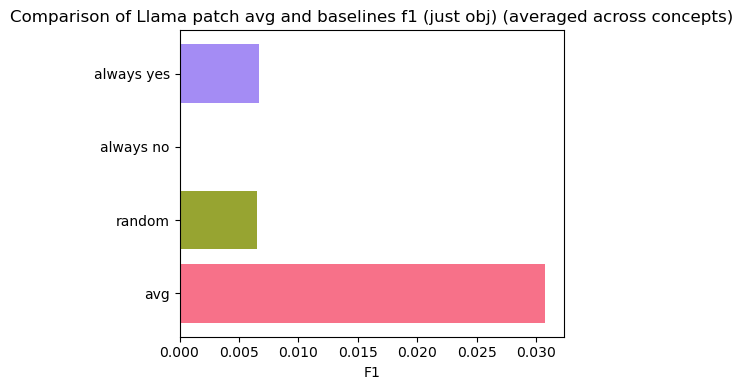

In [49]:
compare_to_baseline(metric_type='f1', 
                    primary_scheme='avg', 
                    dataset_name='Coco', 
                    model_name='Llama', 
                    sample_type='patch',
                    justobj=True,
                    plot_average=True)

## Compare Models

In [50]:
def compare_models(metric_type, primary_scheme, dataset_name, all_models, sample_type, justobj=False, 
                   baseline_type='random', plot_average=True, xmin=None, xmax=None):
    dir = f'Quant_Results/{dataset_name}'
    metric_dfs = {}
    for model_name in all_models:
        if primary_scheme == 'avg':
            path = f'{model_name}_avg_{sample_type}_embeddings_percentthrumodel_100.csv'
        elif primary_scheme == 'linsep (no balancing)':
            path = f'{model_name}_linsep_{sample_type}_embeddings_BD_False_BN_False_percentthrumodel_100.csv'
        elif primary_scheme == 'linsep (overall balancing)':
            path = f'{model_name}_linsep_{sample_type}_embeddings_BD_True_BN_False_percentthrumodel_100.csv'    
        elif primary_scheme == 'linsep (overall and negative balancing)':
            path = f'{model_name}_linsep_{sample_type}_embeddings_BD_True_BN_True_percentthrumodel_100.csv' 
            
        if sample_type == 'patch' and justobj:
            metric_path = f'{dir}/justobj_{path}'
        else:
            metric_path = f'{dir}/{path}'
            
        metric_dfs[model_name] = pd.read_csv(metric_path)
    
    for model_name in all_models:
        if sample_type == 'patch' and justobj:
            baseline_path = f'{dir}/{baseline_type}_justobj_{model_name}_{sample_type}_baseline.csv'
        else:
            baseline_path = f'{dir}/{baseline_type}_{model_name}_{sample_type}_baseline.csv'
        metric_dfs[f'{model_name} {" ".join(baseline_type.split("_"))}'] = pd.read_csv(baseline_path)
    
    
    title = f'Comparison of {primary_scheme} {sample_type} {metric_type} across models'
    if sample_type == 'patch' and justobj:
        title += ' (just obj)'
    if plot_average:
        plot_average_metrics(metric_dfs,
                         metric_type,
                         title = f'{title}\n (averaged across {dataset_name} concepts)',
                         xmin=xmin, xmax=xmax)
    else:
        plot_concept_metrics(metric_dfs,
                         metric_type,
                         title, xmin=xmin, xmax=xmax)

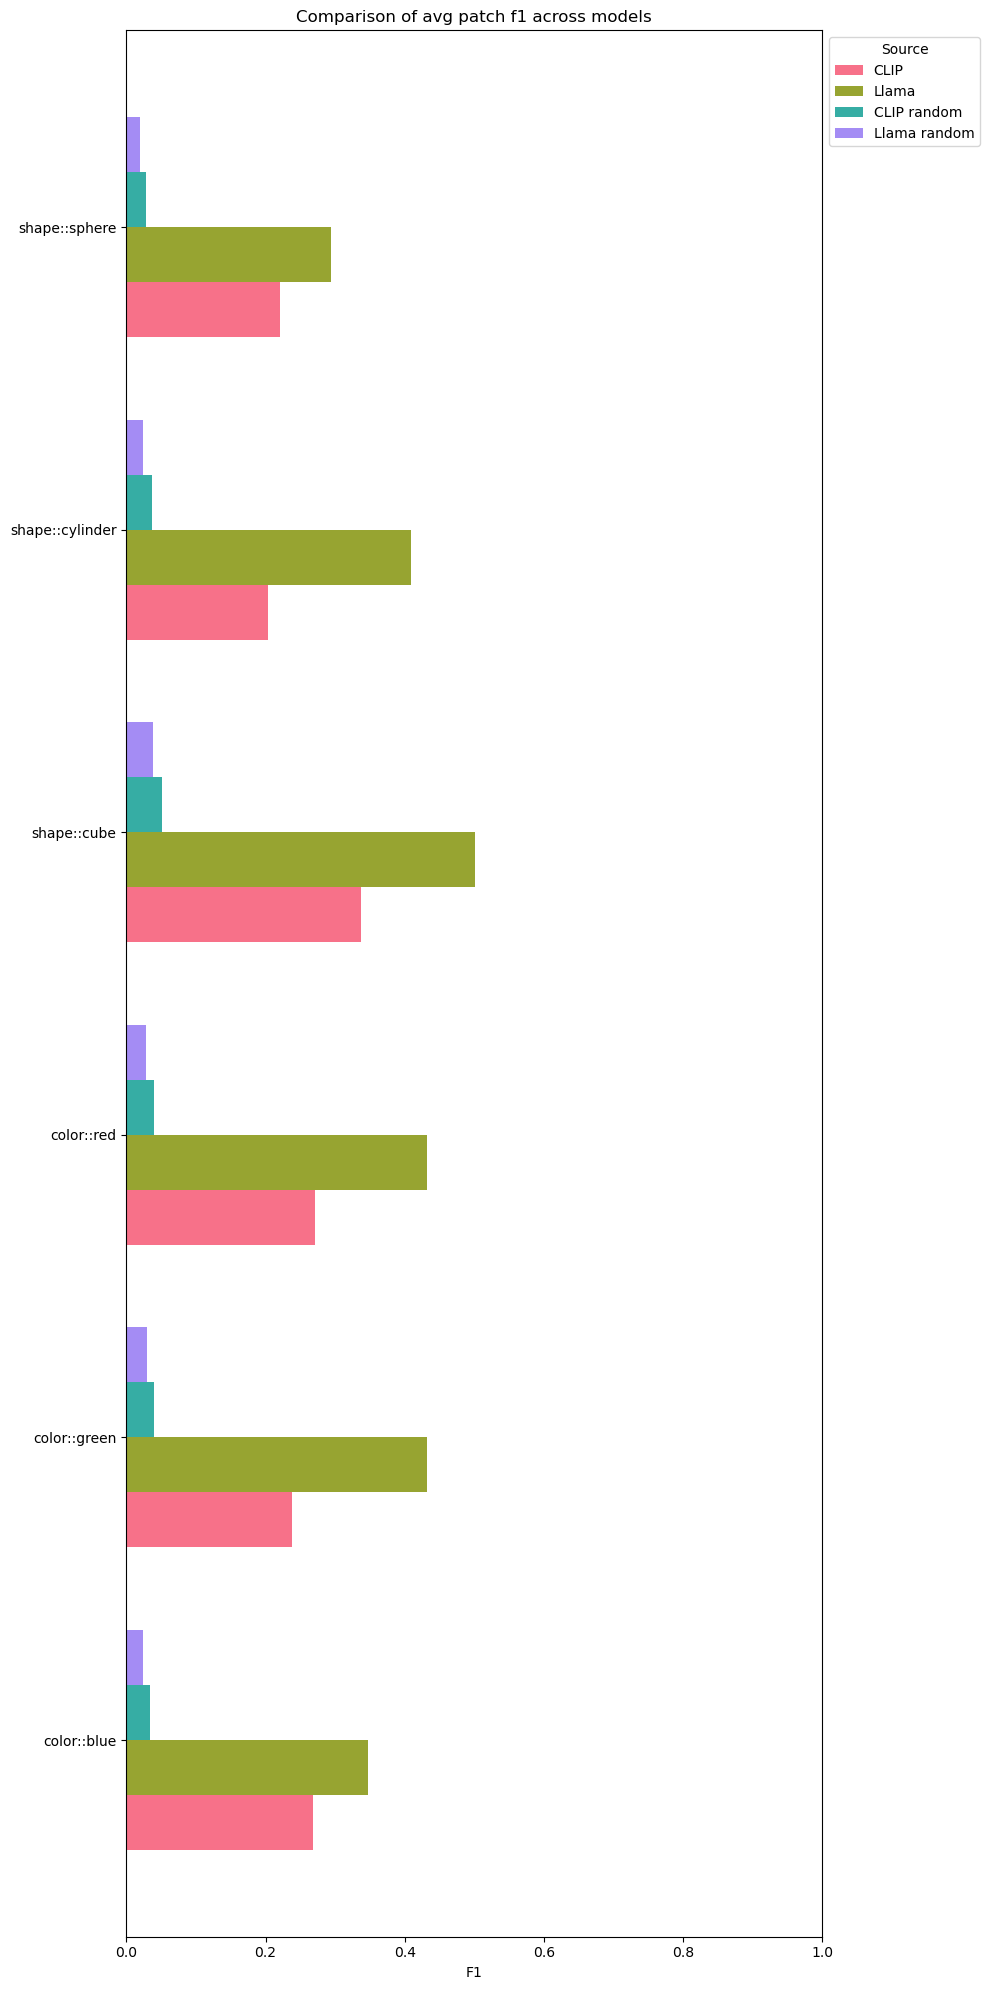

In [51]:
compare_models(metric_type='f1', 
               primary_scheme='avg', 
               dataset_name='CLEVR', 
               all_models=['CLIP', 'Llama'], 
               sample_type='patch', 
               baseline_type='random',
               xmin=0, 
               xmax=1,
               justobj=False,
               plot_average=False)

## Compare Model and Techniques

In [ ]:
def compare_model_performance_across_techniques(metric_type, concept_schemes, dataset_name, 
                                                    all_models, sample_type, curr_concepts=None, justobj=False, 
                                                   baseline_type='random', plot_average=True, 
                                                  xmin=None, xmax=None):
    dir = f'Quant_Results/{dataset_name}'
    model_metric_dfs = {}
    
    #baselines
    baseline_dfs = {}
    for model_name in all_models:
        if sample_type == 'patch' and justobj:
            baseline_path = f'{dir}/{baseline_type}_justobj_{model_name}_{sample_type}_baseline.csv'
        else:
            baseline_path = f'{dir}/{baseline_type}_{model_name}_{sample_type}_baseline.csv'
        baseline_dfs[model_name] = pd.read_csv(baseline_path)
        
    for model_name in all_models: #different models
        scheme_metric_dfs = {}
        for concept_scheme in concept_schemes: #different schemes
            if concept_scheme == 'avg':
                path = f'{model_name}_avg_{sample_type}_embeddings_percentthrumodel_100.csv'
            elif concept_scheme == 'linsep (no balancing)':
                path = f'{model_name}_linsep_{sample_type}_embeddings_BD_False_BN_False_percentthrumodel_100.csv'
            elif concept_scheme == 'linsep (overall balancing)':
                path = f'{model_name}_linsep_{sample_type}_embeddings_BD_True_BN_False_percentthrumodel_100.csv'    
            elif concept_scheme == 'linsep (overall and negative balancing)':
                path = f'{model_name}_linsep_{sample_type}_embeddings_BD_True_BN_True_percentthrumodel_100.csv' 

            if sample_type == 'patch' and justobj:
                metric_path = f'{dir}/justobj_{path}'
            else:
                metric_path = f'{dir}/{path}'

            scheme_metric_dfs[concept_scheme] = pd.read_csv(metric_path)
        model_metric_dfs[model_name] = scheme_metric_dfs
    
    title = f'Avg {metric_type.upper()} for {sample_type.capitalize()} Methods on {dataset_name}'
    if sample_type == 'patch' and justobj:
        title += '\n(Just Obj)'
    
    if plot_average:
        plot_average_grouped_metrics(model_metric_dfs, baseline_dfs, metric_type, baseline_type, 
                                     title=title, xmin=xmin, xmax=xmax)
    else:
        plot_grouped_metrics(model_metric_dfs, baseline_dfs, metric_type, baseline_type,
                             curr_concepts, title=title, xmin=xmin, xmax=xmax)

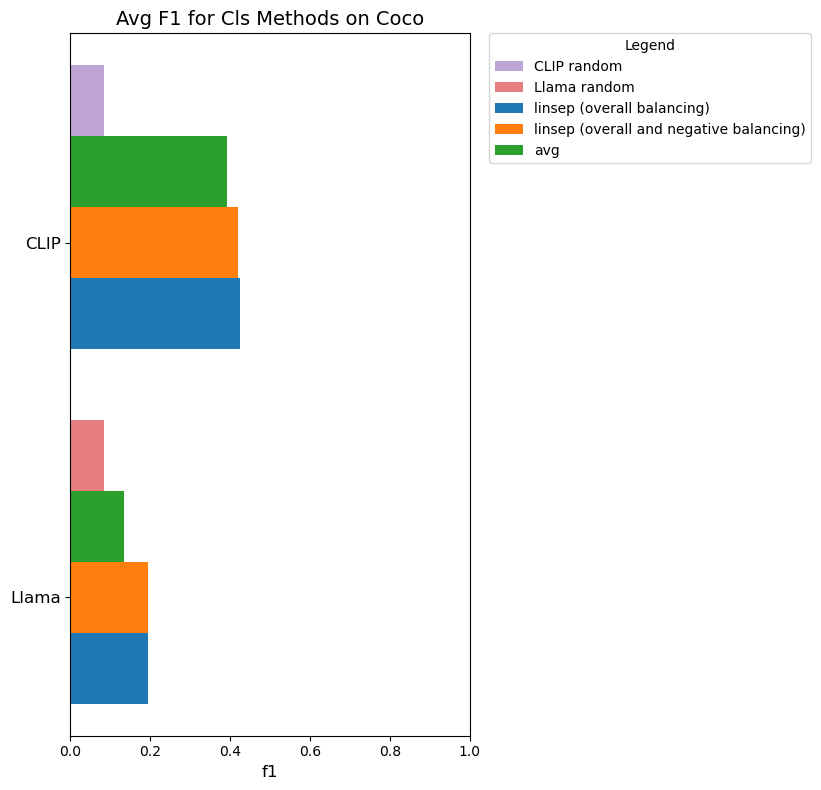

In [867]:
schemes = ['linsep (overall and negative balancing)', 'linsep (overall balancing)', 'avg']
curr_concepts = ['animal', 'person', 'vehicle', 'cow', 'bowl']
compare_model_performance_across_techniques(metric_type='f1', 
                                                concept_schemes=schemes,
                                                dataset_name='Coco', 
                                                all_models=['Llama', 'CLIP'], 
                                                sample_type='cls', 
                                                justobj=False, 
                                                baseline_type='random',
                                                curr_concepts=None,
                                                plot_average=True,
                                                xmin=0, xmax=1)

## Compare Concept Schemes

In [52]:
def compare_schemes(metric_type, concept_schemes, dataset_name, model_name, sample_type, justobj=False, 
                    baseline_type='random', plot_average=True, xmin=None, xmax=None):
    dir = f'Quant_Results/{dataset_name}'
    metric_dfs = {}
    
    #different schemes
    for concept_scheme in concept_schemes:
        if concept_scheme == 'avg':
            path = f'{model_name}_avg_{sample_type}_embeddings_percentthrumodel_100.csv'
        elif concept_scheme == 'linsep (no balancing)':
            path = f'{model_name}_linsep_{sample_type}_embeddings_BD_False_BN_False_percentthrumodel_100.csv'
        elif concept_scheme == 'linsep (overall balancing)':
            path = f'{model_name}_linsep_{sample_type}_embeddings_BD_True_BN_False_percentthrumodel_100.csv'    
        elif concept_scheme == 'linsep (overall and negative balancing)':
            path = f'{model_name}_linsep_{sample_type}_embeddings_BD_True_BN_True_percentthrumodel_100.csv' 
            
        if sample_type == 'patch' and justobj:
            metric_path = f'{dir}/justobj_{path}'
        else:
            metric_path = f'{dir}/{path}'
            
        metric_dfs[concept_scheme] = pd.read_csv(metric_path)
    
    #baseline
    if sample_type == 'patch' and justobj:
        metric_dfs[f'{" ".join(baseline_type.split("_"))}'] = pd.read_csv(f'{dir}/{baseline_type}_justobj_{model_name}_{sample_type}_baseline.csv')
    else:
        metric_dfs[f'{" ".join(baseline_type.split("_"))}'] = pd.read_csv(f'{dir}/{baseline_type}_{model_name}_{sample_type}_baseline.csv')
    
    
    title = f'{metric_type} across {model_name} {sample_type} concept schemes on {dataset_name}'
    if sample_type == 'patch' and justobj:
        title += '\n(just obj)'
    if plot_average:
        plot_average_metrics(metric_dfs,
                         metric_type,
                         title = f'{title}\n(averaged across concepts)',
                          xmin=xmin, xmax=xmax)
    else:
        plot_concept_metrics(metric_dfs,
                         metric_type,
                         title, xmin=xmin, xmax=xmax)

In [57]:
schemes = ['avg', 'linsep (overall balancing)', 'linsep (overall and negative balancing)']
compare_schemes(metric_type='f1', 
                concept_schemes=schemes,
                dataset_name='CLEVR', 
                model_name='CLEVR', 
                sample_type='patch', 
                baseline_type='random', 
                xmin=0, 
                xmax=0.35,
                justobj=False,
                plot_average=False)

FileNotFoundError: [Errno 2] No such file or directory: 'Quant_Results/CLEVR/CLEVR_avg_patch_embeddings_percentthrumodel_100.csv'

# Detection Plots

## Activation Percentage Code

In [63]:
import matplotlib.pyplot as plt
import torch
import numpy as np
import matplotlib.lines as mlines

def plot_activation_percentages(dataset_name, split, model_name, sample_types, weighted_avg=False):
    """
    Plots activation percentages with in-sample percentile on the x-axis and percentage on the y-axis.

    Args:
        dataset_name (str): Name of the dataset.
        split (str): Either "train" or "test".
        model_name (str): Model name
        sample_types (list): List of sample types to include.
    
    Returns:
        None (displays the plot).
    """
    plt.figure(figsize=(8, 6))
    percentiles = [0.02, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 1.0]
    
    con_labels = {}
    for sample_type in sample_types:
        con_labels[f'{sample_type}: avg'] = f'{model_name}_avg_{sample_type}_embeddings_percentthrumodel_100'
        con_labels[f'{sample_type}: linsep (overall bal) '] = f'{model_name}_linsep_{sample_type}_embeddings_BD_True_BN_False_percentthrumodel_100' 
        con_labels[f'{sample_type}: linsep (overall + neg bal) '] = f'{model_name}_linsep_{sample_type}_embeddings_BD_True_BN_True_percentthrumodel_100'

    line_styles = {'In-Concept': '-', 'Out-Concept': '--'}  # Solid for in, dotted for out
    colors = ['red', 'orange', 'yellow', 'green', 'blue', 'purple']

    if model_name == 'CLIP':
        gt_samples_per_concept = torch.load(f'GT_Samples/{dataset_name}/gt_samples_per_concept_{split}_inputsize_(224, 224).pt', weights_only=False)
    elif model_name == 'Llama':
        gt_samples_per_concept = torch.load(f'GT_Samples/{dataset_name}/gt_samples_per_concept_{split}_inputsize_(560, 560).pt', weights_only=False)
    
    #add baselines (HARDCODED)
    if dataset_name == 'Coco':
        tpr = 0.9191
        fpr = 0.1100
    elif dataset_name == 'CLEVR':
        tpr = 1.0000
        fpr = 0.0012
        
    baseline_tprs = [tpr * 100 for _ in range(len(percentiles))]
    baseline_fprs = [fpr * 100 for _ in range(len(percentiles))]
    plt.plot(percentiles, baseline_tprs, color='gray', linestyle=line_styles['In-Concept'], marker='o', label='Prompt-Concept Baseline')
    plt.plot(percentiles, baseline_fprs, color='gray', linestyle=line_styles['Out-Concept'], marker='o')
    
    for i, (name, con_label) in enumerate(con_labels.items()):
        in_percentages, out_percentages = [], []
        for percentile in percentiles:
            in_file_path = f'Quant_Results/{dataset_name}/percentile_{percentile}_{split}_inconcept_{con_label}.pt'
            out_file_path = f'Quant_Results/{dataset_name}/percentile_{percentile}_{split}_outconcept_{con_label}.pt'
            in_pct_data = torch.load(in_file_path, weights_only=False)
            out_pct_data = torch.load(out_file_path, weights_only=False)
            in_pct_data = {k:v for k,v in in_pct_data.items() if k in gt_samples_per_concept.keys()}
            out_pct_data = {k:v for k,v in out_pct_data.items() if k in gt_samples_per_concept.keys()}
            
            if weighted_avg:
                total_in_count = sum(len(gt_samples_per_concept[concept]) for concept in in_pct_data.keys())
                total_out_count = sum(len(gt_samples_per_concept[concept]) for concept in out_pct_data.keys())
                avg_in_percent = sum(percent * len(gt_samples_per_concept[concept]) for concept, percent in in_pct_data.items()) / total_in_count
                avg_out_percent = sum(percent * len(gt_samples_per_concept[concept]) for concept, percent in out_pct_data.items()) /  total_out_count
            else:
                avg_in_percent = sum(in_pct_data.values()) / len(in_pct_data)
                avg_out_percent = sum(out_pct_data.values()) / len(out_pct_data)
            in_percentages.append(avg_in_percent)
            out_percentages.append(avg_out_percent)

        plt.plot(percentiles, in_percentages, linestyle=line_styles['In-Concept'], color=colors[i], marker='o', label=name)
        plt.plot(percentiles, out_percentages, linestyle=line_styles['Out-Concept'], color=colors[i], marker='s')
             
    # Custom legend
    legend_elements = []
    for i, name in enumerate(con_labels.keys()):
        legend_elements.append(plt.Line2D([0], [0], color=colors[i], lw=2, label=name))

    #Baselines 
    legend_elements.append(plt.Line2D([0], [0], color='gray', lw=2, label='Prompt-Concept Baseline'))
             
    # Line style legend for in/out concept
    legend_elements.append(plt.Line2D([0], [0], color='black', linestyle='-', lw=2, label='In-Concept'))
    legend_elements.append(plt.Line2D([0], [0], color='black', linestyle='--', lw=2, label='Out-Concept'))

    plt.ylim(-5, 105)
    plt.xlabel("Chosen In-Sample Percentile")
    plt.ylabel("Image Activation Percentage")
    plt.title(f"Image Activation Percentages for {model_name} on {dataset_name} ({split.capitalize()} split)")

    # Move the legend outside the plot
    plt.legend(handles=legend_elements, title="Concept Discovery Techniques", bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

    plt.grid(True)
    plt.show()
    
    
def plot_activation_percentages_diffs(dataset_name, split, model_name, sample_types, weighted_avg=False):
    """
    Plots the difference between activation percentages.

    Args:
        dataset_name (str): Name of the dataset.
        split (str): Either "train" or "test".
        model_name (str): Model name
        sample_types (list): List of sample types to include.
    
    Returns:
        None (displays the plot).
    """
    plt.figure(figsize=(8, 6))
    percentiles = [0.02, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 1.0]
    
    con_labels = {}
    for sample_type in sample_types:
        con_labels[f'{sample_type}: avg'] = f'{model_name}_avg_{sample_type}_embeddings_percentthrumodel_100'
        con_labels[f'{sample_type}: linsep (overall bal) '] = f'{model_name}_linsep_{sample_type}_embeddings_BD_True_BN_False_percentthrumodel_100' 
        con_labels[f'{sample_type}: linsep (overall + neg bal) '] = f'{model_name}_linsep_{sample_type}_embeddings_BD_True_BN_True_percentthrumodel_100'

    colors = ['red', 'orange', 'yellow', 'green', 'blue', 'purple']

    if model_name == 'CLIP':
        gt_samples_per_concept = torch.load(f'GT_Samples/{dataset_name}/gt_samples_per_concept_{split}_inputsize_(224, 224).pt', weights_only=False)
    elif model_name == 'Llama':
        gt_samples_per_concept = torch.load(f'GT_Samples/{dataset_name}/gt_samples_per_concept_{split}_inputsize_(560, 560).pt', weights_only=False)
    
    #add baselines (HARDCODED)
    if dataset_name == 'Coco':
        tpr = 0.9191
        fpr = 0.1100
    elif dataset_name == 'CLEVR':
        tpr = 1.0000
        fpr = 0.0012
        
    baseline_vals = [(tpr * 100)- (fpr*100) for _ in range(len(percentiles))]
    plt.plot(percentiles, baseline_vals, color='gray', marker='o', label='Prompt-Concept Baseline')
    
    for i, (name, con_label) in enumerate(con_labels.items()):
        percent_diffs = []
        for percentile in percentiles:
            in_file_path = f'Quant_Results/{dataset_name}/percentile_{percentile}_{split}_inconcept_{con_label}.pt'
            out_file_path = f'Quant_Results/{dataset_name}/percentile_{percentile}_{split}_outconcept_{con_label}.pt'
            in_pct_data = torch.load(in_file_path, weights_only=False)
            out_pct_data = torch.load(out_file_path, weights_only=False)
            in_pct_data = {k:v for k,v in in_pct_data.items() if k in gt_samples_per_concept.keys()}
            out_pct_data = {k:v for k,v in out_pct_data.items() if k in gt_samples_per_concept.keys()}
            if weighted_avg:
                total_in_count = sum(len(gt_samples_per_concept[concept]) for concept in in_pct_data.keys())
                total_out_count = sum(len(gt_samples_per_concept[concept]) for concept in out_pct_data.keys())
                avg_in_percent = sum(percent * len(gt_samples_per_concept[concept]) for concept, percent in in_pct_data.items()) / total_in_count
                avg_out_percent = sum(percent * len(gt_samples_per_concept[concept]) for concept, percent in out_pct_data.items()) /  total_out_count
            else:
                avg_in_percent = sum(in_pct_data.values()) / len(in_pct_data)
                avg_out_percent = sum(out_pct_data.values()) / len(out_pct_data)
            percent_diffs.append(avg_in_percent - avg_out_percent)

        plt.plot(percentiles, percent_diffs, color=colors[i], marker='o', label=name)
        
        
    # Custom legend
    legend_elements = []
    for i, name in enumerate(con_labels.keys()):
        legend_elements.append(plt.Line2D([0], [0], color=colors[i], lw=2, label=name))
    #Baselines 
    legend_elements.append(plt.Line2D([0], [0], color='gray', lw=2, label='Prompt-Concept Baseline'))
        
    plt.ylim(-5, 105)
    plt.xlabel("Chosen In-Sample Percentile")
    plt.ylabel("In-concept Act Img % - Out-Concept Img Act %")
    plt.title(f"Image Activation Percentage Differences for {model_name} on {dataset_name} ({split.capitalize()} split)")

    # Move the legend outside the plot
    plt.legend(handles=legend_elements, title="Concept Discovery Techniques", bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

    plt.grid(True)
    plt.show()

## F1 Detection

In [25]:
def plot_detection_scores_per_concept(dataset_name, split, model_name, sample_types, metric='f1', 
                                     concepts_to_plot=None, plot_type='both', n_cols=3):
    """
    Creates a separate subplot for each concept showing detection performance across percentiles.
    
    Args:
        dataset_name (str): Name of the dataset
        split (str): 'train' or 'test' split
        model_name (str): Model name (e.g., 'CLIP', 'Llama')
        sample_types (list): List of sample types (e.g., ['patch', 'cls'])
        metric (str): Metric to plot (default: 'f1')
        concepts_to_plot (list, optional): List of specific concepts to plot. If None, plots all concepts.
        plot_type (str): 'supervised', 'unsupervised', or 'both'
        n_cols (int): Number of columns in the subplot grid
    """
    import math
    import matplotlib.pyplot as plt
    import seaborn as sns
    import os
    
    plt.rcParams.update({'font.size': 8})
    percentiles = [0.02, 0.05, 0.1, 0.2, 0.3, 0.4, 0.6, 0.8, 0.9, 0.95]
    
    # Load ground truth samples
    if dataset_name == 'Stanford-Tree-Bank' or 'Sarcasm' in dataset_name:
        gt_samples_per_concept = torch.load(f"GT_Samples/{dataset_name}/gt_samples_per_concept_{split}_inputsize_('text', 'text').pt", weights_only=False)
    elif model_name == 'CLIP':
        gt_samples_per_concept = torch.load(f'GT_Samples/{dataset_name}/gt_samples_per_concept_{split}_inputsize_(224, 224).pt', weights_only=False)
    elif model_name == 'Llama':
        gt_samples_per_concept = torch.load(f'GT_Samples/{dataset_name}/gt_samples_per_concept_{split}_inputsize_(560, 560).pt', weights_only=False)
    
    # Determine which concepts to plot
    if concepts_to_plot is None:
        concepts_to_plot = sorted(list(gt_samples_per_concept.keys()))
    else:
        # Filter to only concepts that exist in the dataset
        concepts_to_plot = [c for c in concepts_to_plot if c in gt_samples_per_concept]
    
    if not concepts_to_plot:
        print("No valid concepts to plot.")
        return
    
    # Setup concept labels
    con_labels = {}
    for sample_type in sample_types:
        n_clusters = 1000 if sample_type == 'patch' else 50
        if plot_type in ('supervised', 'both'):
            con_labels[f'labeled {sample_type} avg'] = f'{model_name}_avg_{sample_type}_embeddings_percentthrumodel_100'
            con_labels[f'labeled {sample_type} linsep'] = f'{model_name}_linsep_{sample_type}_embeddings_BD_True_BN_False_percentthrumodel_100'
        if plot_type in ('unsupervised', 'both'):
            con_labels[f'unsupervised {sample_type} kmeans'] = f'{model_name}_kmeans_{n_clusters}_{sample_type}_embeddings_kmeans_percentthrumodel_100'
            con_labels[f'unsupervised {sample_type} linsep kmeans'] = f'{model_name}_kmeans_{n_clusters}_linsep_{sample_type}_embeddings_kmeans_percentthrumodel_100'
    
    # Style mapping
    style_map = {
        'labeled patch avg': {'color': 'orchid', 'type': 'supervised', 'label': 'patch avg'},
        'labeled patch linsep': {'color': 'indigo', 'type': 'supervised', 'label': 'patch linsep'},
        'labeled cls avg': {'color': 'goldenrod', 'type': 'supervised', 'label': 'cls avg'},
        'labeled cls linsep': {'color': 'orangered', 'type': 'supervised', 'label': 'cls linsep'},
        'unsupervised patch kmeans': {'color': 'orchid', 'type': 'unsupervised', 'label': 'patch avg'},
        'unsupervised patch linsep kmeans': {'color': 'indigo', 'type': 'unsupervised', 'label': 'patch linsep'},
        'unsupervised cls kmeans': {'color': 'goldenrod', 'type': 'unsupervised', 'label': 'cls avg'},
        'unsupervised cls linsep kmeans': {'color': 'orangered', 'type': 'unsupervised', 'label': 'cls linsep'},
    }
    
    # Calculate subplot layout
    n_concepts = len(concepts_to_plot)
    n_rows = math.ceil(n_concepts / n_cols)
    
    # Create figure with subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    if n_concepts == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if n_rows > 1 or n_cols > 1 else [axes]
    
    # Get prompt scores if available
    try:
        prompt_scores = get_prompt_scores(dataset_name, metric)
    except:
        prompt_scores = None
    
    # Plot for each concept
    for idx, concept in enumerate(concepts_to_plot):
        ax = axes[idx]
        
        # Plot prompt baselines if available
        if prompt_scores and metric == 'f1' and concept in prompt_scores:
            ax.axhline(prompt_scores[concept][0], color='#8B4513', linestyle='-.', linewidth=1.5, label="Prompt1" if idx == 0 else None)
            ax.axhline(prompt_scores[concept][1], color='#D2B48C', linestyle='-.', linewidth=1.5, label="Prompt2" if idx == 0 else None)
        
        # Plot baseline CSVs
        baseline_style_map = {
            'random': {'color': '#888888', 'label': 'Random'},
            'always_yes': {'color': '#bbbbbb', 'label': 'Always Pos'},
            'always_no': {'color': '#dddddd', 'label': 'Always Neg'}
        }
        
        for baseline_type in ['random', 'always_yes', 'always_no']:
            baseline_path = f'Quant_Results/{dataset_name}/{baseline_type}_{model_name}_cls_baseline.csv'
            if os.path.exists(baseline_path):
                df = pd.read_csv(baseline_path)
                concept_row = df[df['concept'] == concept]
                if not concept_row.empty:
                    score = concept_row.iloc[0][metric]
                    style = baseline_style_map[baseline_type]
                    ax.axhline(score, color=style['color'], linestyle='-.', linewidth=1, 
                              label=style['label'] if idx == 0 else None)
        
        # Plot concept discovery methods
        for name, con_label in con_labels.items():
            scores = []
            valid_percentiles = []
            
            for percentile in percentiles:
                try:
                    detection_metrics = torch.load(
                        f'Quant_Results/{dataset_name}/detectionmetrics_per_{percentile}_{con_label}.pt', 
                        weights_only=False
                    )
                    concept_metrics = detection_metrics[detection_metrics['concept'] == concept]
                    if not concept_metrics.empty:
                        scores.append(concept_metrics.iloc[0][metric])
                        valid_percentiles.append(percentile)
                except FileNotFoundError:
                    continue
            
            if scores:
                style = style_map.get(name, {})
                color = style.get('color', 'gray')
                kind = style.get('type', 'supervised')
                label = style.get('label', name)
                linestyle = ':' if plot_type == 'both' and kind == 'unsupervised' else '-'
                
                # Only show label in first subplot to avoid legend duplication
                plot_label = label if idx == 0 else None
                ax.plot(valid_percentiles, scores, color=color, linestyle=linestyle, 
                       marker='o', markersize=3, label=plot_label)
        
        # Formatting for each subplot
        ax.set_xlabel("Concept Recall %", fontsize=10)
        ax.set_ylabel(f"{metric.upper()} Score", fontsize=10)
        ax.set_title(f"{concept}", fontsize=11, fontweight='bold')
        ax.set_ylim(0, 1.05)
        ax.set_xlim(0, 1)
        ax.set_xticks(np.linspace(0, 1.0, 6))
        ax.set_xticklabels([f"{int(x*100)}%" for x in np.linspace(0, 1.0, 6)])
        ax.grid(True, linestyle='--', linewidth=0.3)
    
    # Remove empty subplots
    for idx in range(n_concepts, len(axes)):
        fig.delaxes(axes[idx])
    
    # Add overall title
    fig.suptitle(f"Detection Performance by Concept - {model_name} on {dataset_name}", 
                 fontsize=14, fontweight='bold')
    
    # Add legend to the first subplot or figure
    if n_concepts > 0:
        handles, labels = axes[0].get_legend_handles_labels()
        if handles:
            fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1, 0.5), 
                      title="Method", fontsize=8)
    
    plt.tight_layout()
    plt.show()

In [27]:
def get_prompt_scores(dataset_name, metric):
    if dataset_name == 'Coco':
        # first element prompt: 'output all concepts present in the image'
        # second element prompt: 'Does the image contain X?'
        concept_f1s = {
            'bed': (0.5490196078431373, 0.29743589743589743),
            'surfboard': (0.5, 0.8666666666666666),
            'bicycle': (0.5263157894736843, 0.6236559139784946),
            'spoon': (0.43609022556390975, 0.45283018867924535),
            'pizza': (0.8, 0.8450704225352113),
            'fork': (0.3544303797468354, 0.3851851851851852),
            'train': (0.813953488372093, 0.6728971962616822),
            'motorcycle': (0.6153846153846153, 0.7246376811594204),
            'tennis racket': (0.9350649350649352, 0.9333333333333333),
            'sports ball': (0.4807692307692308, 0.6206896551724138),
            'potted plant': (0.16445623342175064, 0.24267782426778245),
            'umbrella': (0.7536231884057972, 0.5934065934065935),
            'dog': (0.5714285714285715, 0.5904761904761905),
            'knife': (0.44736842105263164, 0.5384615384615384),
            'laptop': (0.3636363636363636, 0.5979381443298969),
            'cat': (0.7951807228915663, 0.7816091954022989),
            'sink': (0.6417910447761194, 0.5540540540540541),
            'bus': (0.7961165048543688, 0.5443037974683544),
            'traffic light': (0.7474747474747475, 0.7659574468085106),
            'couch': (0.4429530201342282, 0.5000000000000001),
            'clock': (0.38918918918918916, 0.4320987654320988),
            'tv': (0.3135593220338983, 0.4714285714285714),
            'cell phone': (0.29773462783171517, 0.619718309859155),
            'backpack': (0.5606060606060606, 0.5483870967741935),
            'book': (0.4696969696969696, 0.2907488986784141),
            'bench': (0.37010676156583633, 0.22698072805139186),
            'truck': (0.5777777777777778, 0.4277456647398844),
            'handbag': (0.43824701195219123, 0.5213270142180095),
            'bowl': (0.37249283667621774, 0.33780160857908853),
            'appliance': (0.22333333333333333, 0.38040345821325644),
            'bottle': (0.4545454545454545, 0.5118110236220472),
            'cup': (0.44728434504792336, 0.4930555555555556),
            'dining table': (0.7400881057268722, 0.6953405017921146),
            'car': (0.7850467289719627, 0.6149253731343284),
            'outdoor': (0.35658914728682173, 0.3562340966921119),
            'chair': (0.36645962732919257, 0.5248868778280542),
            'electronic': (0.24629418472063852, 0.4855769230769231),
            'indoor': (0.3400936037441497, 0.30559345156889495),
            'food': (0.7901907356948228, 0.8011204481792717),
            'accessory': (0.2526115859449193, 0.2682403433476395),
            'kitchen': (0.6453333333333334, 0.628415300546448),
            'sports': (0.8293838862559242, 0.8661417322834646),
            'animal': (0.6633825944170771, 0.8056112224448897),
            'vehicle': (0.7845117845117846, 0.8528864059590316),
            'furniture': (0.5175438596491228, 0.6750788643533122),
            'person': (0.9447513812154695, 0.9281961471103327)
        }

        tpr = 0.9191
        fpr = 0.1100
        
    elif dataset_name == 'CLEVR':
        concept_f1s = {
            'color::blue': (1.0, 1.0), 'color::green': (1.0, 1.0), 'color::red': (1.0, 1.0),
            'shape::cube': (1.0, 1.0), 'shape::cylinder': (0.9917355371900827, 0.9917355371900827), 'shape::sphere': (1.0, 1.0)
        }
        tpr = 1.0000
        fpr = 0.0012
    elif dataset_name == 'Broden-Pascal':
        concept_f1s = {
            'color::black-c': (0.5, 0.5),
            'color::blue-c': (0.5, 0.5),
            'color::brown-c': (0.5, 0.5),
            'color::green-c': (0.5, 0.5),
            'color::grey-c': (0.5, 0.5),
            'color::orange-c': (0.5, 0.5),
            'color::pink-c': (0.5, 0.5),
            'color::purple-c': (0.5, 0.5),
            'color::red-c': (0.5, 0.5),
            'color::white-c': (0.5, 0.5),
            'color::yellow-c': (0.5, 0.5),
            'object::airplane': (0.5, 0.5),
            'object::bicycle': (0.5, 0.5),
            'object::bird': (0.5, 0.5),
            'object::boat': (0.5, 0.5),
            'object::body': (0.5, 0.5),
            'object::book': (0.5, 0.5),
            'object::building': (0.5, 0.5),
            'object::bus': (0.5, 0.5),
            'object::cap': (0.5, 0.5),
            'object::car': (0.5, 0.5),
            'object::cat': (0.5, 0.5),
            'object::cup': (0.5, 0.5),
            'object::dog': (0.5, 0.5),
            'object::door': (0.5, 0.5),
            'object::ear': (0.5, 0.5),
            'object::engine': (0.5, 0.5),
            'object::grass': (0.5, 0.5),
            'object::hair': (0.5, 0.5),
            'object::horse': (0.5, 0.5),
            'object::leg': (0.5, 0.5),
            'object::mirror': (0.5, 0.5),
            'object::motorbike': (0.5, 0.5),
            'object::mountain': (0.5, 0.5),
            'object::painting': (0.5, 0.5),
            'object::person': (0.5, 0.5),
            'object::pottedplant': (0.5, 0.5),
            'object::saddle': (0.5, 0.5),
            'object::screen': (0.5, 0.5),
            'object::sky': (0.5, 0.5),
            'object::sofa': (0.5, 0.5),
            'object::table': (0.5, 0.5),
            'object::track': (0.5, 0.5),
            'object::train': (0.5, 0.5),
            'object::tvmonitor': (0.5, 0.5),
            'object::wheel': (0.5, 0.5),
            'object::wood': (0.5, 0.5),
            'part::arm': (0.5, 0.5),
            'part::bag': (0.5, 0.5),
            'part::beak': (0.5, 0.5),
            'part::bottle': (0.5, 0.5),
            'part::box': (0.5, 0.5),
            'part::cabinet': (0.5, 0.5),
            'part::ceiling': (0.5, 0.5),
            'part::chain wheel': (0.5, 0.5),
            'part::chair': (0.5, 0.5),
            'part::coach': (0.5, 0.5),
            'part::curtain': (0.5, 0.5),
            'part::eye': (0.5, 0.5),
            'part::eyebrow': (0.5, 0.5),
            'part::fabric': (0.5, 0.5),
            'part::fence': (0.5, 0.5),
            'part::floor': (0.5, 0.5),
            'part::foot': (0.5, 0.5),
            'part::ground': (0.5, 0.5),
            'part::hand': (0.5, 0.5),
            'part::handle bar': (0.5, 0.5),
            'part::head': (0.5, 0.5),
            'part::headlight': (0.5, 0.5),
            'part::light': (0.5, 0.5),
            'part::mouth': (0.5, 0.5),
            'part::muzzle': (0.5, 0.5),
            'part::neck': (0.5, 0.5),
            'part::nose': (0.5, 0.5),
            'part::paw': (0.5, 0.5),
            'part::plant': (0.5, 0.5),
            'part::plate': (0.5, 0.5),
            'part::plaything': (0.5, 0.5),
            'part::pole': (0.5, 0.5),
            'part::pot': (0.5, 0.5),
            'part::road': (0.5, 0.5),
            'part::rock': (0.5, 0.5),
            'part::rope': (0.5, 0.5),
            'part::shelves': (0.5, 0.5),
            'part::sidewalk': (0.5, 0.5),
            'part::signboard': (0.5, 0.5),
            'part::stern': (0.5, 0.5),
            'part::tail': (0.5, 0.5),
            'part::torso': (0.5, 0.5),
            'part::tree': (0.5, 0.5),
            'part::wall': (0.5, 0.5),
            'part::water': (0.5, 0.5),
            'part::windowpane': (0.5, 0.5),
            'part::wing': (0.5, 0.5),
        }
        tpr = 0.5
        fpr = 0.5
        
    elif dataset_name == 'Broden-OpenSurfaces':
        concept_f1s = {
            'color::black-c': (0.5, 0.5),
            'color::blue-c': (0.5, 0.5),
            'color::brown-c': (0.5, 0.5),
            'color::green-c': (0.5, 0.5),
            'color::grey-c': (0.5, 0.5),
            'color::orange-c': (0.5, 0.5),
            'color::pink-c': (0.5, 0.5),
            'color::purple-c': (0.5, 0.5),
            'color::red-c': (0.5, 0.5),
            'color::white-c': (0.5, 0.5),
            'color::yellow-c': (0.5, 0.5),
            'material::brick': (0.5, 0.5),
            'material::cardboard': (0.5, 0.5),
            'material::carpet': (0.5, 0.5),
            'material::ceramic': (0.5, 0.5),
            'material::concrete': (0.5, 0.5),
            'material::fabric': (0.5, 0.5),
            'material::food': (0.5, 0.5),
            'material::fur': (0.5, 0.5),
            'material::glass': (0.5, 0.5),
            'material::granite': (0.5, 0.5),
            'material::hair': (0.5, 0.5),
            'material::laminate': (0.5, 0.5),
            'material::leather': (0.5, 0.5),
            'material::metal': (0.5, 0.5),
            'material::mirror': (0.5, 0.5),
            'material::painted': (0.5, 0.5),
            'material::paper': (0.5, 0.5),
            'material::plastic-clear': (0.5, 0.5),
            'material::plastic-opaque': (0.5, 0.5),
            'material::rock': (0.5, 0.5),
            'material::rubber': (0.5, 0.5),
            'material::skin': (0.5, 0.5),
            'material::tile': (0.5, 0.5),
            'material::wallpaper': (0.5, 0.5),
            'material::wicker': (0.5, 0.5),
            'material::wood': (0.5, 0.5),
        }
        tpr=0.5
        fpr=0.5
    elif dataset_name == 'Stanford-Tree-Bank' or 'Sarcasm' in dataset_name:
        concept_f1s = {
            'positive': (0.5, 0.5),
            'negative': (0.5, 0.5)}
        tpr=0.5
        fpr=0.5
 
    if metric == 'f1':
        return concept_f1s
    elif metric == 'tpr':
        return tpr
    elif metric == 'fpr':
        return fpr


import torch
import matplotlib.pyplot as plt

def plot_predictions_vs_percentiles(dataset_name, model_name, sample_type, concept, scheme='avg', split='test'):
    """
    For a given concept and scheme, plots:
    - Predicted Positives and Predicted Negatives over percentiles
    - Horizontal lines for Ground Truth Positives and Negatives
    """

    percentiles = [0.02, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]

    # === Construct con_label based on scheme
    n_clusters = 1000 if sample_type == 'patch' else 50

    if scheme == 'avg':
        con_labels = {
            f'labeled {sample_type} avg': f'{model_name}_avg_{sample_type}_embeddings_percentthrumodel_100'
        }
    elif scheme == 'linsep':
        con_labels = {
            f'labeled {sample_type} linsep': f'{model_name}_linsep_{sample_type}_embeddings_BD_True_BN_False_percentthrumodel_100'
        }
    elif scheme == 'kmeans':
        con_labels = {
            f'unsupervised {sample_type} kmeans': f'{model_name}_kmeans_{n_clusters}_{sample_type}_embeddings_kmeans_percentthrumodel_100'
        }
    elif scheme == 'kmeans linsep':
        con_labels = {
            f'unsupervised {sample_type} linsep kmeans': f'{model_name}_kmeans_{n_clusters}_linsep_{sample_type}_embeddings_kmeans_percentthrumodel_100'
        }
    else:
        raise ValueError(f"Unsupported scheme: {scheme}")

    # === Plotting
    plt.figure(figsize=(10, 6))

    for method_name, con_label in con_labels.items():
        pred_pos_counts = []
        pred_neg_counts = []
        gt_pos = None
        gt_neg = None
        valid_percentiles = []

        for pct in percentiles:
            try:
                df = torch.load(
                    f'Quant_Results/{dataset_name}/detectionmetrics_per_{pct}_{con_label}.pt',
                    weights_only=False
                )
            except FileNotFoundError:
                continue

            df = df[df['concept'] == concept]
            if df.empty:
                continue

            row = df.iloc[0]
            tp, tn, fp, fn = int(row['tp']), int(row['tn']), int(row['fp']), int(row['fn'])

            pred_pos_counts.append(tp + fp)
            pred_neg_counts.append(tn + fn)
            valid_percentiles.append(pct)

            if gt_pos is None:
                gt_pos = tp + fn
                gt_neg = tn + fp

        if pred_pos_counts:
            plt.plot(valid_percentiles, pred_pos_counts, marker='o', label=f"{method_name} - Pred Pos")
            plt.plot(valid_percentiles, pred_neg_counts, marker='s', label=f"{method_name} - Pred Neg")

    if gt_pos is not None:
        plt.axhline(y=gt_pos, color='green', linestyle='--', label=f"GT Positives = {gt_pos}")
    if gt_neg is not None:
        plt.axhline(y=gt_neg, color='purple', linestyle='--', label=f"GT Negatives = {gt_neg}")

    plt.title(f"Predicted Counts vs Percentile for Concept: '{concept}' ({scheme})")
    plt.xlabel("Percentile Threshold")
    plt.ylabel("Sample Count")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    
def plot_detection_scores(dataset_name, split, model_name, sample_types, metric='f1', weighted_avg=True, plot_type='both'):
    save_path = f'../Figs/Paper_Figs/{model_name}_{dataset_name}_detectplot.pdf'
    plt.figure(figsize=(10, 7))
    percentiles = [0.02, 0.05, 0.1, 0.2, 0.3, 0.4, 0.6, 0.8, 0.9, 0.95]
    plt.rcParams.update({'font.size': 8})

    con_labels = {}
    for sample_type in sample_types:
        n_clusters = 1000 if sample_type == 'patch' else 50
        if plot_type in ('supervised', 'both'):
            con_labels[f'labeled {sample_type} avg'] = f'{model_name}_avg_{sample_type}_embeddings_percentthrumodel_100'
            con_labels[f'labeled {sample_type} linsep'] = f'{model_name}_linsep_{sample_type}_embeddings_BD_True_BN_False_percentthrumodel_100'
        if plot_type in ('unsupervised', 'both'):
            con_labels[f'unsupervised {sample_type} kmeans'] = f'{model_name}_kmeans_{n_clusters}_{sample_type}_embeddings_kmeans_percentthrumodel_100'
            con_labels[f'unsupervised {sample_type} linsep kmeans'] = f'{model_name}_kmeans_{n_clusters}_linsep_{sample_type}_embeddings_kmeans_percentthrumodel_100'

    style_map = {
        'labeled patch avg': {'color': 'orchid', 'type': 'supervised', 'label': 'patch avg'},
        'labeled patch linsep': {'color': 'indigo', 'type': 'supervised', 'label': 'patch linsep'},
        'labeled cls avg': {'color': 'goldenrod', 'type': 'supervised', 'label': 'cls avg'},
        'labeled cls linsep': {'color': 'orangered', 'type': 'supervised', 'label': 'cls linsep'},
        'unsupervised patch kmeans': {'color': 'orchid', 'type': 'unsupervised', 'label': 'patch avg'},
        'unsupervised patch linsep kmeans': {'color': 'indigo', 'type': 'unsupervised', 'label': 'patch linsep'},
        'unsupervised cls kmeans': {'color': 'goldenrod', 'type': 'unsupervised', 'label': 'cls avg'},
        'unsupervised cls linsep kmeans': {'color': 'orangered', 'type': 'unsupervised', 'label': 'cls linsep'},
    }

    if dataset_name == 'Stanford-Tree-Bank' or 'Sarcasm' in dataset_name:
        gt_samples_per_concept = torch.load(f"GT_Samples/{dataset_name}/gt_samples_per_concept_{split}_inputsize_('text', 'text').pt", weights_only=False)
    elif model_name == 'CLIP':
        gt_samples_per_concept = torch.load(f'GT_Samples/{dataset_name}/gt_samples_per_concept_{split}_inputsize_(224, 224).pt', weights_only=False)
    elif model_name == 'Llama':
        gt_samples_per_concept = torch.load(f'GT_Samples/{dataset_name}/gt_samples_per_concept_{split}_inputsize_(560, 560).pt', weights_only=False)

    try:
        prompt_scores = get_prompt_scores(dataset_name, metric)
        if metric == 'f1':
            filtered = {k: v for k, v in prompt_scores.items() if k in gt_samples_per_concept}
            if weighted_avg:
                total = sum(len(gt_samples_per_concept[k]) for k in filtered)
                avg_prompt1 = sum(v[0] * len(gt_samples_per_concept[k]) for k, v in filtered.items()) / total
                avg_prompt2 = sum(v[1] * len(gt_samples_per_concept[k]) for k, v in filtered.items()) / total
            else:
                avg_prompt1 = np.mean([v[0] for v in filtered.values()])
                avg_prompt2 = np.mean([v[1] for v in filtered.values()])
        else:
            avg_prompt1 = avg_prompt2 = prompt_scores
        plt.axhline(avg_prompt1, color='#8B4513', linestyle='-.', linewidth=2, label="Prompt1 (All Concepts)")
        plt.axhline(avg_prompt2, color='#D2B48C', linestyle='-.', linewidth=2, label="Prompt2 (Is X Present)")
    except:
        pass

    # Baseline CSVs: random, always_yes, always_no
    baseline_style_map = {
        'random':      {'color': '#888888', 'label': 'Random'},
        'always_yes':  {'color': '#bbbbbb', 'label': 'Always Pos'},
        'always_no':   {'color': '#dddddd', 'label': 'Always Neg'}
    }

    for baseline_type in ['random', 'always_yes', 'always_no']:
        style = baseline_style_map[baseline_type]
        baseline_path = f'Quant_Results/{dataset_name}/{baseline_type}_{model_name}_cls_baseline.csv'
        if not os.path.exists(baseline_path):
            continue
        df = pd.read_csv(baseline_path)
        df = df[df['concept'].isin(gt_samples_per_concept)]
        if weighted_avg:
            total = sum(len(gt_samples_per_concept[c]) for c in df['concept'])
            score = sum(row[metric] * len(gt_samples_per_concept[row['concept']]) for _, row in df.iterrows()) / total
        else:
            score = df[metric].mean()
        plt.axhline(score, color=style['color'], linestyle='-.', linewidth=1.5, label=style['label'])

    seen_labels = set()
    for name, con_label in con_labels.items():
        scores = []
        for percentile in percentiles:
            detection_metrics = torch.load(f'Quant_Results/{dataset_name}/detectionmetrics_per_{percentile}_{con_label}.pt', weights_only=False)
            detection_metrics = detection_metrics[detection_metrics['concept'].isin(gt_samples_per_concept)]
            if weighted_avg:
                total = sum(len(gt_samples_per_concept[c]) for c in detection_metrics['concept'])
                score = sum(row[metric] * len(gt_samples_per_concept[row['concept']]) for _, row in detection_metrics.iterrows()) / total
            else:
                score = detection_metrics[metric].mean()
            scores.append(score)

        style = style_map[name]
        color = style['color']
        kind = style['type']
        label = style['label']
        linestyle = ':' if plot_type == 'both' and kind == 'unsupervised' else '-'
        plot_label = label if label not in seen_labels else None
        seen_labels.add(label)
        plt.plot(percentiles, scores, color=color, linestyle=linestyle, marker='o', markersize=4, label=plot_label)

    plt.xlabel("Concept Recall Percentage", fontsize=14)
    plt.ylabel(f"{metric.upper()} Score", fontsize=14)
    plt.ylim(0, 1.05)
    plt.xlim(0, 1)
    plt.xticks(np.linspace(0, 1.0, 11), [f"{int(x*100)}%" for x in np.linspace(0, 1.0, 11)])
    if dataset_name == 'Stanford-Tree-Bank':
        plt.title(f"Sentence-Level Detection Performance", fontweight='bold', fontsize=14)
    elif 'Sarcasm' in dataset_name:
        plt.title(f"Paragraph-Level Detection Performance", fontweight='bold', fontsize=14)
    else:
        plt.title(f"Image-Level Detection Performance", fontweight='bold', fontsize=14)
    plt.grid(True, linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.legend(title="Concept Type", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.savefig(save_path, dpi=500, format='pdf', bbox_inches='tight')
    plt.show()
    
    
def summarize_best_detection_scores(dataset_name, split, model_name, sample_types, metric='f1', weighted_avg=True):
    """
    Returns a DataFrame summarizing the best detection score (and the percentile it occurs at)
    for each concept discovery method.
    """

    percentiles = [0.02, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]
    
    # === Construct concept label mappings
    con_labels = {}
    for sample_type in sample_types:
        n_clusters = 1000 if sample_type == 'patch' else 50
        con_labels[f'labeled {sample_type} avg'] = f'{model_name}_avg_{sample_type}_embeddings_percentthrumodel_100'
        con_labels[f'labeled {sample_type} linsep'] = f'{model_name}_linsep_{sample_type}_embeddings_BD_True_BN_False_percentthrumodel_100'
        con_labels[f'unsupervised {sample_type} kmeans'] = f'{model_name}_kmeans_{n_clusters}_{sample_type}_embeddings_kmeans_percentthrumodel_100'
        con_labels[f'unsupervised {sample_type} linsep kmeans'] = f'{model_name}_kmeans_{n_clusters}_linsep_{sample_type}_embeddings_kmeans_percentthrumodel_100'

    # === Load ground-truth labels
    if dataset_name == 'Stanford-Tree-Bank' or 'Sarcasm' in dataset_name:
        gt_samples_per_concept = torch.load(f"GT_Samples/{dataset_name}/gt_samples_per_concept_{split}_inputsize_('text', 'text').pt", weights_only=False)
    elif model_name == 'CLIP':
        gt_samples_per_concept = torch.load(f'GT_Samples/{dataset_name}/gt_samples_per_concept_{split}_inputsize_(224, 224).pt', weights_only=False)
    elif model_name == 'Llama':
        gt_samples_per_concept = torch.load(f'GT_Samples/{dataset_name}/gt_samples_per_concept_{split}_inputsize_(560, 560).pt', weights_only=False)

    results = []

    for name, con_label in con_labels.items():
        best_score = -1
        best_percentile = None 
        for percentile in percentiles:
            try:
                detection_metrics = torch.load(f'Quant_Results/{dataset_name}/detectionmetrics_per_{percentile}_{con_label}.pt', weights_only=False)
            except FileNotFoundError:
                continue

            detection_metrics = detection_metrics[detection_metrics['concept'].isin(gt_samples_per_concept.keys())]

            if weighted_avg:
                total_samples = sum(len(gt_samples_per_concept[c]) for c in detection_metrics['concept'])
                weighted_sum = 0

                for _, row in detection_metrics.iterrows():
                    n_samples = len(gt_samples_per_concept[row['concept']])
                    weighted_sum += row[metric] * n_samples

                score = weighted_sum / total_samples if total_samples > 0 else 0
            else:
                score = detection_metrics[metric].mean()

            if score > best_score:
                best_score = score
                best_percentile = percentile

        results.append({
            'Method': name,
            f'Best {metric.upper()}': round(best_score, 4),
            'Percentile': best_percentile
        })

    return pd.DataFrame(results)


from collections import defaultdict
def summarize_best_detection_scores_per_concept(dataset_name, split, model_name, sample_types, metric='f1'):
    """
    Returns a DataFrame showing, for each concept and discovery method,
    the best detection score and the corresponding percentile.

    Columns: [concept, method, best_<metric>, percentile]
    """
    percentiles = [0.02, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]

    # === Build concept discovery labels
    con_labels = {}
    for sample_type in sample_types:
        n_clusters = 1000 if sample_type == 'patch' else 50
        con_labels[f'labeled {sample_type} avg'] = f'{model_name}_avg_{sample_type}_embeddings_percentthrumodel_100'
        con_labels[f'labeled {sample_type} linsep'] = f'{model_name}_linsep_{sample_type}_embeddings_BD_True_BN_False_percentthrumodel_100'
        con_labels[f'unsupervised {sample_type} kmeans'] = f'{model_name}_kmeans_{n_clusters}_{sample_type}_embeddings_kmeans_percentthrumodel_100'
        con_labels[f'unsupervised {sample_type} linsep kmeans'] = f'{model_name}_kmeans_{n_clusters}_linsep_{sample_type}_embeddings_kmeans_percentthrumodel_100'

    # === Load GT concepts
    if dataset_name == 'Stanford-Tree-Bank' or 'Sarcasm' in dataset_name:
        gt_path = f"GT_Samples/{dataset_name}/gt_samples_per_concept_{split}_inputsize_('text', 'text').pt"
    elif model_name == 'CLIP':
        gt_path = f'GT_Samples/{dataset_name}/gt_samples_per_concept_{split}_inputsize_(224, 224).pt'
    elif model_name == 'Llama':
        gt_path = f'GT_Samples/{dataset_name}/gt_samples_per_concept_{split}_inputsize_(560, 560).pt'
    gt_concepts = torch.load(gt_path, weights_only=False)

    results = []

    for method_name, con_label in con_labels.items():
        per_concept_best = defaultdict(lambda: (-1, None))  # concept -> (best_score, best_percentile)

        for percentile in percentiles:
            try:
                df = torch.load(f'Quant_Results/{dataset_name}/detectionmetrics_per_{percentile}_{con_label}.pt', weights_only=False)
            except FileNotFoundError:
                continue

            df = df[df['concept'].isin(gt_concepts.keys())]

            for _, row in df.iterrows():
                c = row['concept']
                score = row[metric]

                if score > per_concept_best[c][0]:
                    per_concept_best[c] = (score, percentile)

        for concept, (score, percentile) in per_concept_best.items():
            results.append({
                'concept': concept,
                'method': method_name,
                f'best_{metric}': round(score, 4),
                'percentile': percentile
            })

    return pd.DataFrame(results)

## In vs Out-Concept Activation Percentages

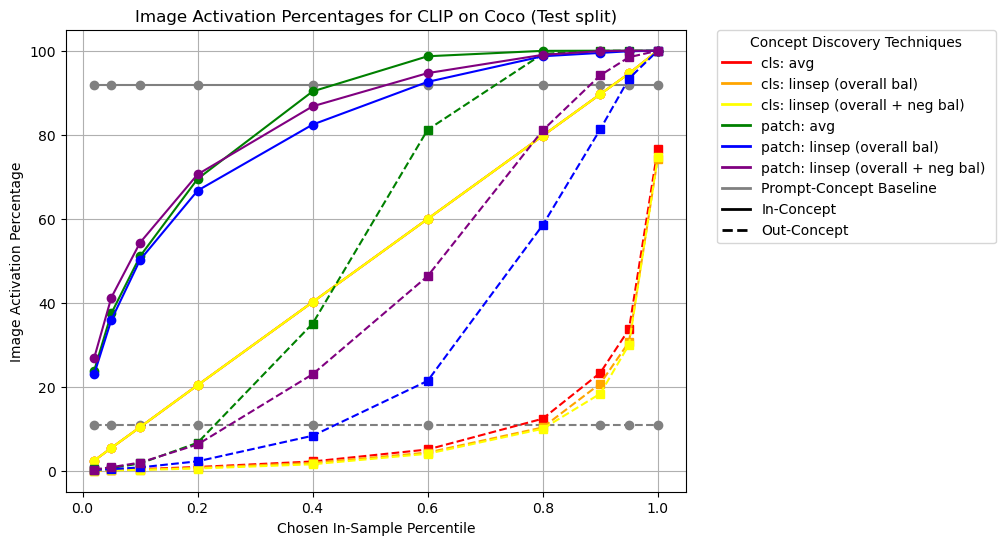

In [6]:
# Example usage
plot_activation_percentages(dataset_name='Coco',
                            split='test',
                            model_name = 'CLIP',
                            sample_types = ['cls', 'patch'],
                            weighted_avg=True)

## Diff Between In-Sample/Out of Sample Activation Percentages 

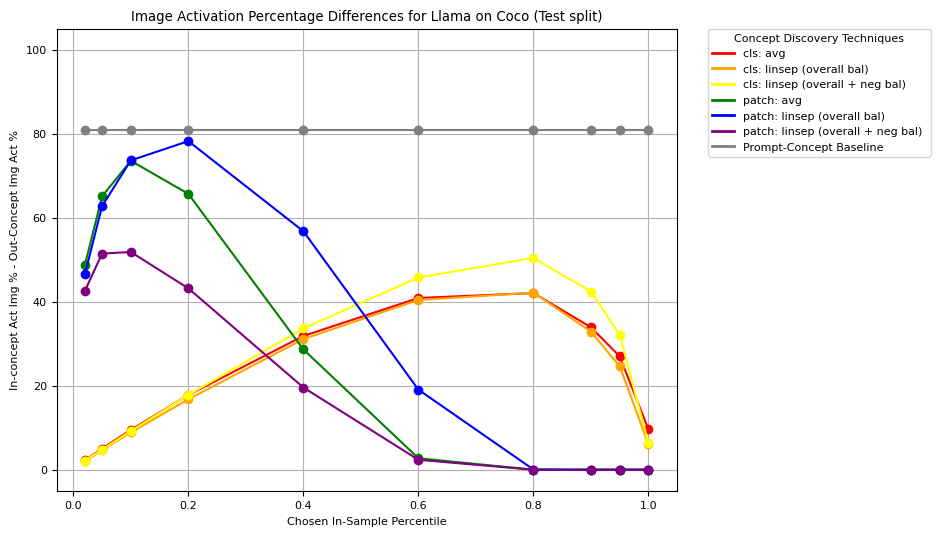

In [33]:
plot_activation_percentages_diffs(dataset_name='Coco',
                            split='test',
                            model_name = 'Llama',
                            sample_types = ['cls', 'patch'],
                            weighted_avg=True)

## Show Pred Counts

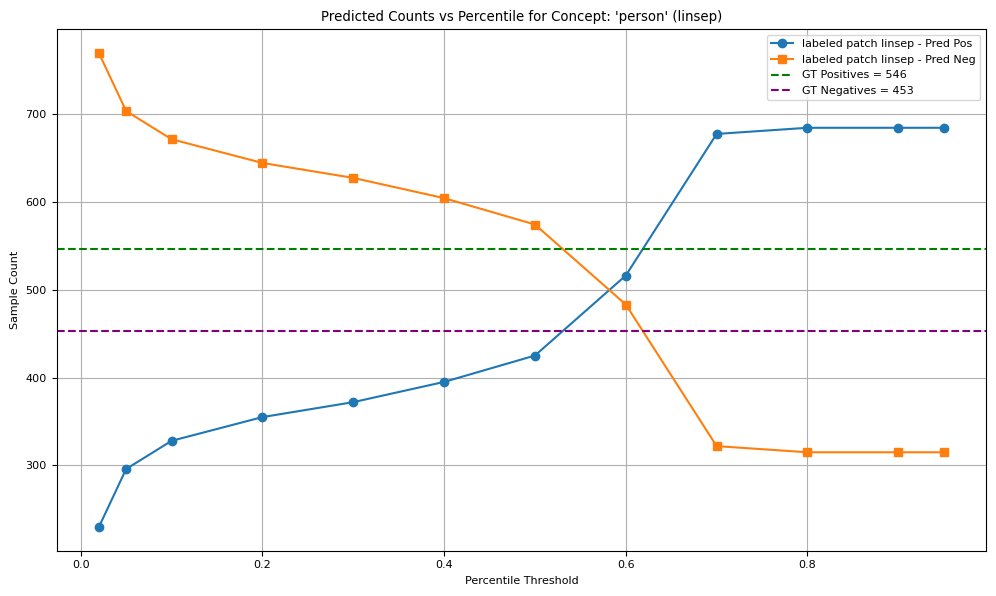

In [28]:
plot_predictions_vs_percentiles(dataset_name='Coco', 
                                model_name='Llama', 
                                sample_type='patch', 
                                scheme = 'linsep',
                                concept='person', 
                                split='test')

## Metrics for Detection

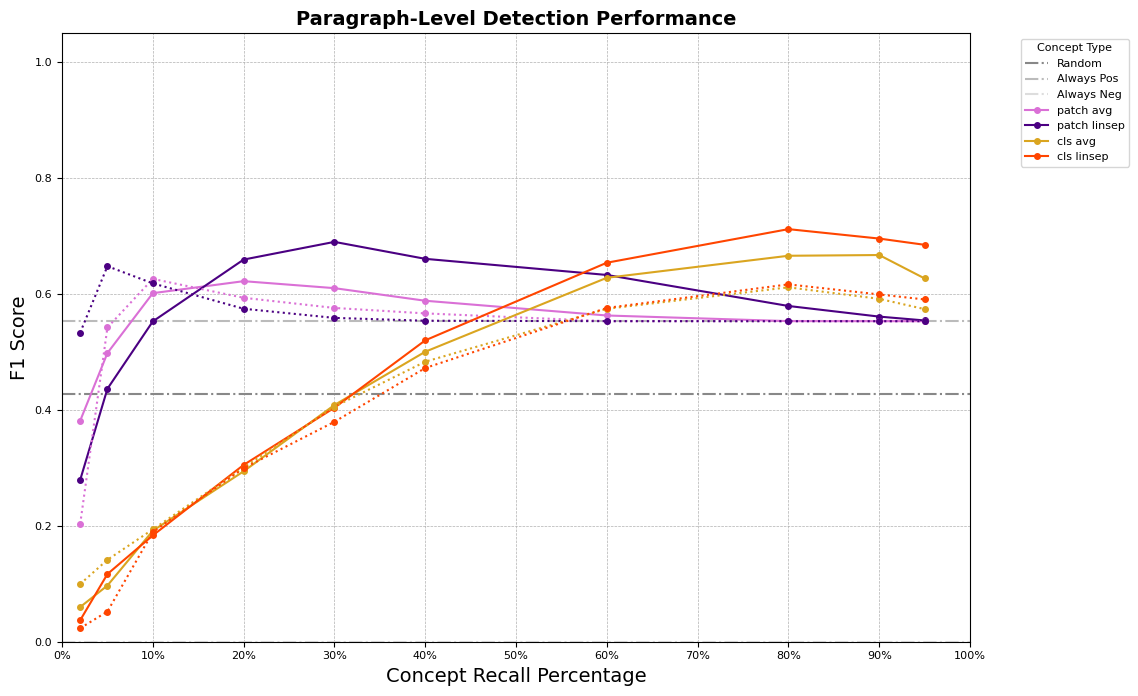

In [29]:
plot_detection_scores(dataset_name='iSarcasm',
                split='test',
                model_name = 'Llama',
                sample_types = ['patch', 'cls'],
                metric='f1',
                plot_type='both',
                weighted_avg=True)

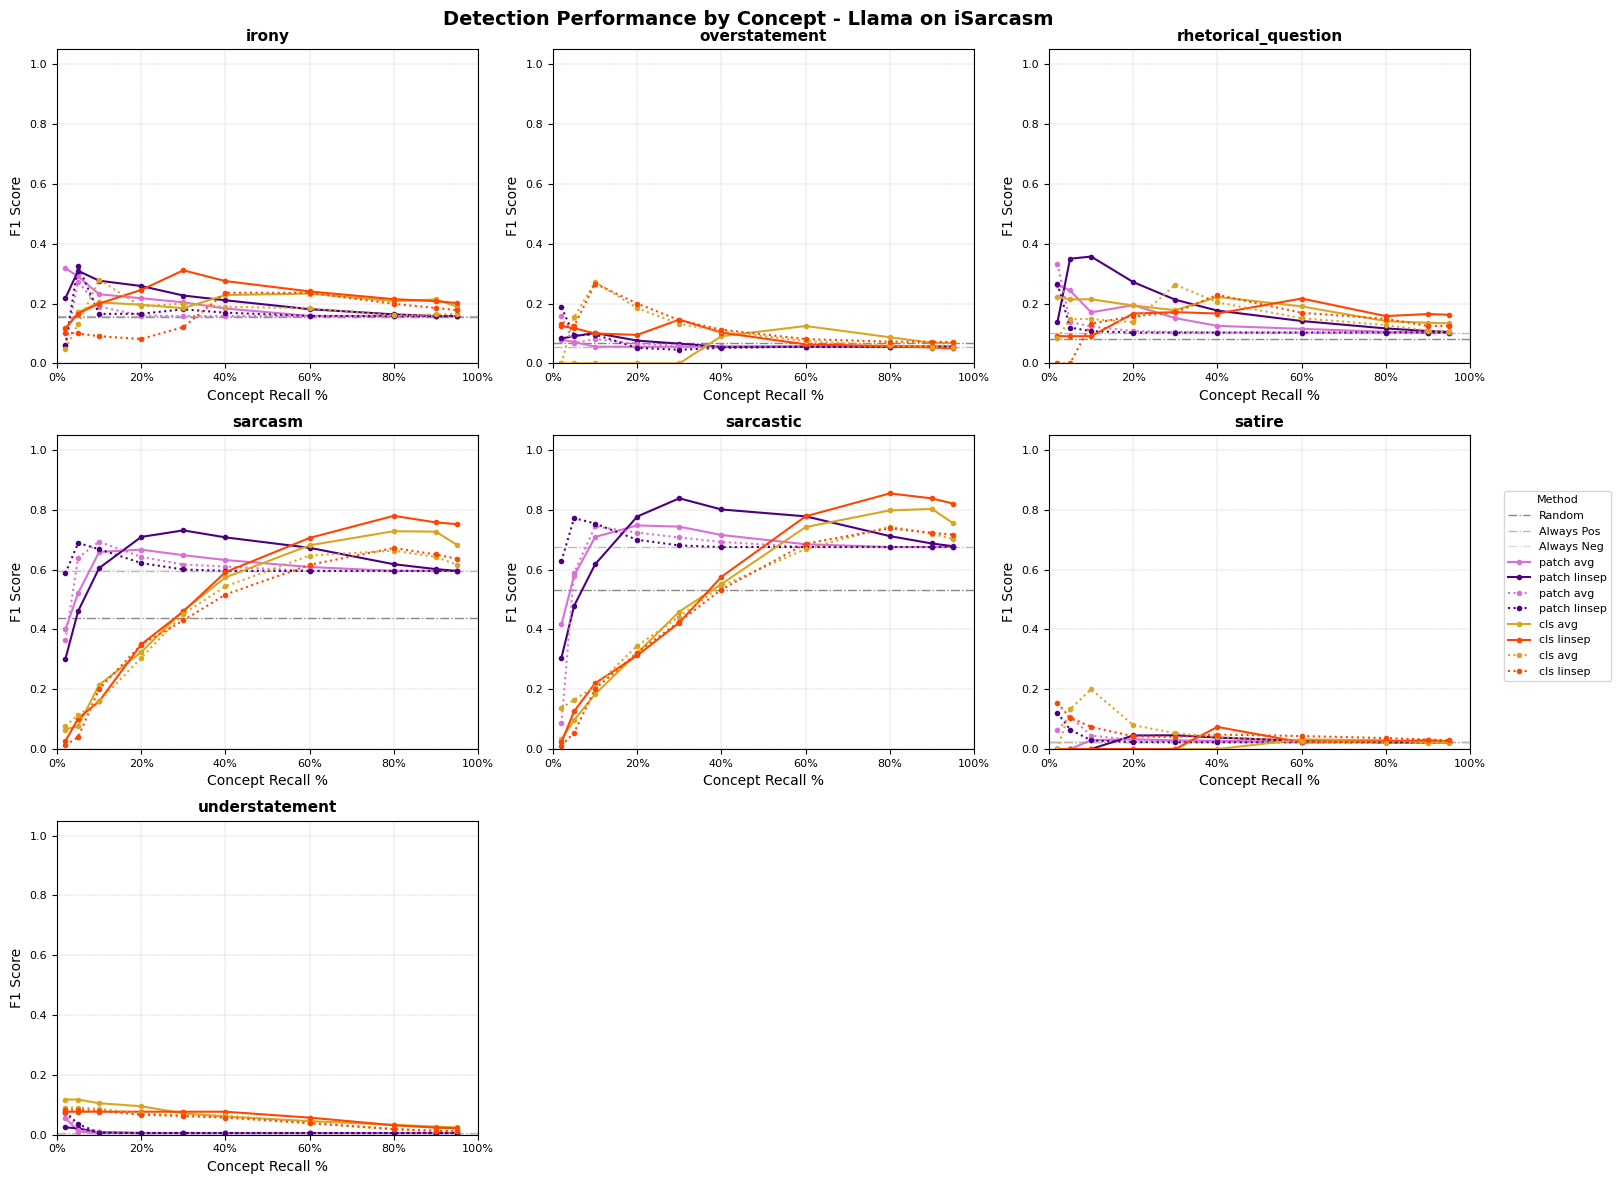

In [28]:
plot_detection_scores_per_concept(dataset_name='iSarcasm', 
                                  split='test', 
                                  model_name='Llama', 
                                  sample_types=['patch', 'cls'], 
                                  metric='f1', 
                                  concepts_to_plot=None, 
                                  plot_type='both',
                                  n_cols=3)

In [15]:
summarize_best_detection_scores(dataset_name='Coco',
                                     split='test', 
                                     model_name='CLIP', 
                                     sample_types=['patch', 'cls'],
                                     metric='f1', 
                                     weighted_avg=True)

/tmp/ipykernel_381/3540141627.py:441: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gt_samples_per_concept = torch.load(f'GT_Samples/{dataset_name}/gt_samples_per_concept_{s

,Method,Best F1,Percentile
0,labeled patch avg,0.6718,0.2
1,labeled patch linsep,0.7181,0.3
2,unsupervised patch kmeans,0.6369,0.1
3,unsupervised patch linsep kmeans,0.6509,0.1
4,labeled cls avg,0.6403,0.7
5,labeled cls linsep,0.6618,0.8
6,unsupervised cls kmeans,0.5601,0.7
7,unsupervised cls linsep kmeans,0.5664,0.7


In [24]:
summarize_best_detection_scores_per_concept(dataset_name = 'iSarcasm', 
                                            split='test', 
                                            model_name = 'Llama', 
                                            sample_types = ['patch', 'cls'], 
                                            metric='f1')

,concept,method,best_f1,percentile
0,irony,labeled patch avg,0.3182,0.02
1,overstatement,labeled patch avg,0.0794,0.02
2,rhetorical_question,labeled patch avg,0.2623,0.02
3,sarcasm,labeled patch avg,0.6667,0.20
4,sarcastic,labeled patch avg,0.7477,0.20
5,satire,labeled patch avg,0.0326,0.20
6,understatement,labeled patch avg,0.0571,0.02
7,irony,labeled patch linsep,0.3095,0.05
8,overstatement,labeled patch linsep,0.1017,0.10
9,rhetorical_question,labeled patch linsep,0.3571,0.10


# Compare Best Performing Detect/Invert Combo Across Techniques

In [33]:
import pandas as pd
import math

def compare_best_schemes(metric_type, concept_schemes, dataset_name, model_name, detect_percents, invert_percents,
                         justobj=False, superdetector_inversion=False, xmin=None, xmax=None, weighted_avg=True):

    dir = f'Quant_Results/{dataset_name}'
    best_metric_dfs = {}
    

    # Load ground truth sample sizes
    if model_name == 'CLIP':
        gt_path = f'GT_Samples/{dataset_name}/gt_samples_per_concept_test_inputsize_(224, 224).pt'
    elif model_name == 'Llama':
        gt_path = f'GT_Samples/{dataset_name}/gt_samples_per_concept_test_inputsize_(560, 560).pt'
    gt_samples_per_concept = torch.load(gt_path, weights_only=False)

    for concept_scheme in concept_schemes:
        best_avg_metric = -float('inf')
        best_df = None
        best_detect = None
        best_invert = None

        for detect_percentile in detect_percents:
            for invert_percentile in invert_percents:
                if invert_percentile < detect_percentile:
                    continue

                path = f'detectfirst_{detect_percentile*100}_per_{invert_percentile*100}'
                if superdetector_inversion:
                    path += '_superpatch_avg_inv'
                path += f'_{model_name}'
                if concept_scheme == 'avg':
                    path += '_avg_patch_embeddings_percentthrumodel_100.csv'
                elif concept_scheme == 'linsep':
                    path += '_linsep_patch_embeddings_BD_True_BN_False_percentthrumodel_100.csv'
                elif concept_scheme == 'unsupervised kmeans':
                    path += f'_kmeans_1000_patch_embeddings_kmeans_percentthrumodel_100.csv'
                elif concept_scheme == 'unsupervised kmeans linsep':
                    path += f'_kmeans_1000_linsep_patch_embeddings_kmeans_percentthrumodel_100.csv'
                else:
                    raise ValueError(f"Unrecognized concept scheme: {concept_scheme}")

                if justobj:
                    metric_path = f'{dir}/justobj_{path}'
                else:
                    metric_path = f'{dir}/{path}'

                try:
                    df = pd.read_csv(metric_path)
                except FileNotFoundError:
                    print(f"Warning: File not found {metric_path}, skipping.")
                    continue

                df = df[df['concept'].isin(gt_samples_per_concept.keys())]

                if weighted_avg:
                    total_samples = sum(len(gt_samples_per_concept[c]) for c in df['concept'])
                    weighted_sum = 0

                    for _, row in df.iterrows():
                        n_samples = len(gt_samples_per_concept[row['concept']])
                        weighted_sum += row[metric_type] * n_samples

                    avg_metric = weighted_sum / total_samples if total_samples > 0 else 0
                else:
                    avg_metric = df[metric_type].mean()

                if avg_metric > best_avg_metric:
                    best_avg_metric = avg_metric
                    best_df = df
                    best_detect = detect_percentile
                    best_invert = invert_percentile

        if best_df is not None:
            best_metric_dfs[f"{concept_scheme}\n(detect={best_detect}, invert={best_invert})"] = best_df
        else:
            print(f"No valid metrics found for {concept_scheme}.")

    # Now plot the best metrics
    title = f"Best {metric_type.capitalize()} for {model_name} Patch Schemes on {dataset_name}"
    if superdetector_inversion:
        title += "\n(Local Superdetector Inversion)"
    plot_average_metrics(best_metric_dfs, metric_type, 
                         title=title, 
                         xmin=xmin, xmax=xmax)

import importlib
import unsupervised_utils
importlib.reload(unsupervised_utils)
from unsupervised_utils import get_matched_concepts_and_data   
def compare_best_schemes_per_concept(metric_type, concept_schemes, dataset_name, model_name,
                                     detect_percents, invert_percents, justobj=False,
                                     superdetector_inversion=False, concepts_to_plot=None,
                                     xmin=None, xmax=None, n_cols=3):
    """
    For each concept separately, plots the best metric achieved by each scheme using subplots (3 per row).

    Args:
        metric_type (str): Metric to plot ('f1', 'accuracy', etc.)
        concept_schemes (list): List of concept schemes (e.g., 'avg', 'linsep - overall balancing', etc.)
        dataset_name (str): Dataset name.
        model_name (str): Model name.
        detect_percents (list): Detection percentiles.
        invert_percents (list): Inversion percentiles.
        justobj (bool): Whether to use object-only patches.
        superdetector_inversion (bool): Whether to use superdetector inversion paths.
        concepts_to_plot (list): List of concepts to plot (default = all concepts).
        xmin (float, optional): Min x-axis limit.
        xmax (float, optional): Max x-axis limit.
        n_cols (int): Number of subplots per row (default=3)
    """

    base_dir = f'Quant_Results/{dataset_name}'
    
    concept_to_best_metrics = {}

    for concept_scheme in concept_schemes:
        best_metrics_per_concept = {}

        for detect_percentile in detect_percents:
            for invert_percentile in invert_percents:
                if invert_percentile < detect_percentile:
                    continue

                path = f'detectfirst_{detect_percentile*100}_per_{invert_percentile*100}'
                if superdetector_inversion:
                    path += '_superpatch_avg_inv'
                path += f'_{model_name}'

                if concept_scheme == 'avg':
                    path += '_avg_patch_embeddings_percentthrumodel_100.csv'
                elif concept_scheme == 'linsep':
                    path += '_linsep_patch_embeddings_BD_True_BN_False_percentthrumodel_100.csv'
                elif concept_scheme == 'unsupervised kmeans':
                    path += f'_kmeans_1000_patch_embeddings_kmeans_percentthrumodel_100.csv'
                elif concept_scheme == 'unsupervised kmeans linsep':
                    path += f'_kmeans_1000_linsep_patch_embeddings_BD_True_BN_False_kmeans_percentthrumodel_100.csv'
                else:
                    raise ValueError(f"Unrecognized concept scheme: {concept_scheme}")

                metric_path = f'{base_dir}/justobj_{path}' if justobj else f'{base_dir}/{path}'

                try:
                    df = pd.read_csv(metric_path)
                except FileNotFoundError:
                    print(f"Warning: File not found {metric_path}, skipping.")
                    continue

                for idx, row in df.iterrows():
                    concept = row['concept']
                    score = row[metric_type]

                    if concept not in best_metrics_per_concept or score > best_metrics_per_concept[concept][0]:
                        best_metrics_per_concept[concept] = (score, detect_percentile, invert_percentile)

        concept_to_best_metrics[concept_scheme] = best_metrics_per_concept

    # Now prepare plotting
    all_concepts = set()
    for scheme_best in concept_to_best_metrics.values():
        all_concepts.update(scheme_best.keys())

    if concepts_to_plot is None:
        concepts_to_plot = sorted(list(all_concepts))

    n_concepts = len(concepts_to_plot)
    n_rows = math.ceil(n_concepts / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = axes.flatten()

    for idx, concept in enumerate(concepts_to_plot):
        ax = axes[idx]
        
        scores = []
        labels = []

        for concept_scheme in concept_schemes:
            if concept in concept_to_best_metrics[concept_scheme]:
                score, detect, invert = concept_to_best_metrics[concept_scheme][concept]
                scores.append(score)
                labels.append(f"{concept_scheme}\n(detect={detect}, invert={invert})")
            else:
                scores.append(0.0)
                labels.append(f"{concept_scheme}\n(not found)")

        colors = sns.color_palette("husl", len(labels))
        bars = ax.barh(labels, scores, color=colors)

        # Annotate
        for bar, value in zip(bars, scores):
            ax.text(
                bar.get_width() + 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{value:.2f}",
                va='center',
                ha='left',
                fontsize=9,
                fontweight='bold'
            )

        ax.set_title(f"{concept}", fontsize=11)
        ax.set_xlim(left=xmin if xmin is not None else 0, right=xmax if xmax is not None else 1)
        ax.set_xlabel(metric_type.capitalize())
        ax.grid(axis='x', linestyle='--', linewidth=0.5)

    # Hide unused subplots
    for i in range(n_concepts, len(axes)):
        fig.delaxes(axes[i])

    plt.suptitle(f"Best {metric_type.capitalize()} per Concept ({model_name} on {dataset_name})",
                 fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
    

def summarize_best_inversion_metrics(metric_type, concept_schemes, dataset_name, model_name, detect_percents, invert_percents,
                                     justobj=False, superdetector_inversion=False, weighted_avg=True):
    """
    Summarizes the best average metric (e.g., F1, TPR) for each concept scheme across detect/invert percentiles.

    Returns:
        pd.DataFrame: One row per concept scheme with best score and corresponding detect/invert thresholds.
    """

    base_dir = f'Quant_Results/{dataset_name}'
    summary_rows = []

    # Load ground truth sample sizes
    if model_name == 'CLIP':
        gt_path = f'GT_Samples/{dataset_name}/gt_samples_per_concept_test_inputsize_(224, 224).pt'
    elif model_name == 'Llama':
        gt_path = f'GT_Samples/{dataset_name}/gt_samples_per_concept_test_inputsize_(560, 560).pt'
    gt_samples_per_concept_test = torch.load(gt_path, weights_only=False)

    for concept_scheme in concept_schemes:
        best_avg_metric = -float('inf')
        best_detect = None
        best_invert = None
        best_file = None

        for detect_percentile in detect_percents:
            for invert_percentile in invert_percents:
                if invert_percentile < detect_percentile:
                    continue

                path = f'detectfirst_{int(detect_percentile*100)}.0_per_{int(invert_percentile*100)}.0'
                if superdetector_inversion:
                    path += '_superpatch_avg_inv'
                path += f'_{model_name}'

                if concept_scheme == 'avg':
                    path += '_avg_patch_embeddings_percentthrumodel_100.csv'
                elif concept_scheme == 'linsep':
                    path += '_linsep_patch_embeddings_BD_True_BN_False_percentthrumodel_100.csv'
                elif concept_scheme == 'unsupervised kmeans':
                    con_label = f"{model_name}_kmeans_1000_patch_embeddings_kmeans_percentthrumodel_100"
                    path += '_kmeans_1000_patch_embeddings_kmeans_percentthrumodel_100.csv'
                elif concept_scheme == 'unsupervised kmeans linsep':
                    con_label = f"{model_name}_kmeans_1000_linsep_patch_embeddings_kmeans_percentthrumodel_100"
                    path += '_kmeans_1000_linsep_patch_embeddings_kmeans_percentthrumodel_100.csv'
                else:
                    raise ValueError(f"Unrecognized concept scheme: {concept_scheme}")

                metric_path = os.path.join(base_dir, f'justobj_{path}' if justobj else path)

                if not os.path.exists(metric_path):
                    print(metric_path)
                    continue

                df = pd.read_csv(metric_path) 
    
                if 'kmeans' in concept_scheme:
                    alignment_path = f'Unsupervised_Matches/{dataset_name}/bestdetects_{con_label}.pt'
                    alignment_results = torch.load(alignment_path, weights_only=False)
                    cluster_to_concept = {str(info['best_cluster']): concept for concept, info in alignment_results.items()}
                    df = df.copy()
                    df['concept'] = df['concept'].astype(str).map(cluster_to_concept)
                
                df = df[df['concept'].isin(gt_samples_per_concept_test.keys())].reset_index(drop=True)

                if weighted_avg:
                    total_samples = sum(len(gt_samples_per_concept_test[c]) for c in df['concept'])
                    weighted_sum = 0

                    for _, row in df.iterrows():
                        n_samples = len(gt_samples_per_concept_test[row['concept']])
                        weighted_sum += row[metric_type] * n_samples

                    avg_metric = weighted_sum / total_samples if total_samples > 0 else 0
                else:
                    avg_metric = df[metric_type].mean()

                if avg_metric > best_avg_metric:
                    best_avg_metric = avg_metric
                    best_detect = detect_percentile
                    best_invert = invert_percentile
                    best_file = path

        if superdetector_inversion:
            scheme_name = f'{concept_scheme} superdetector cossim'
        else:
            scheme_name = f'{concept_scheme} concept cossim'

        summary_rows.append({
            'Scheme': scheme_name,
            f'Best Avg {metric_type.upper()}': round(best_avg_metric, 4) if best_avg_metric > -1 else None,
            'Detect %': best_detect,
            'Invert %': best_invert,
            'File': best_file
        })

    return pd.DataFrame(summary_rows)


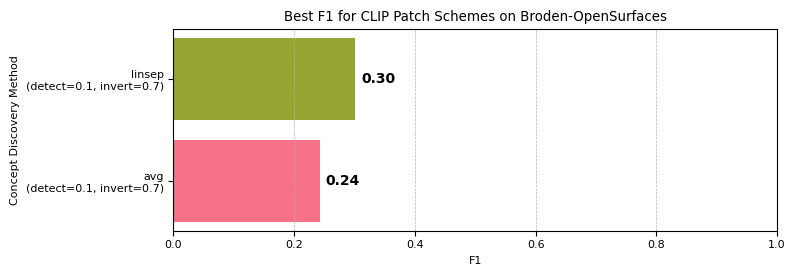

In [35]:
schemes = ['avg', 'linsep', 'unsupervised kmeans', 'unsupervised kmeans linsep']
percentiles = [0.02, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.95]
compare_best_schemes(metric_type='f1', 
                     concept_schemes=schemes, 
                     dataset_name='Broden-OpenSurfaces', 
                     model_name='CLIP', 
                     detect_percents=percentiles, 
                     invert_percents=percentiles,
                     superdetector_inversion=False,
                     justobj=False, 
                     xmin=0.0, 
                     xmax=1.0)

In [53]:
percentiles = [0.02, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.95]
summarize_best_inversion_metrics(metric_type='f1', 
                                 concept_schemes=['avg', 'linsep', 'unsupervised kmeans', 'unsupervised kmeans linsep'], 
                                 dataset_name='Broden-Pascal', 
                                 model_name='CLIP', 
                                 detect_percents=percentiles, 
                                 invert_percents=percentiles,
                                 justobj=False, 
                                 superdetector_inversion=True)


,Scheme,Best Avg F1,Detect %,Invert %,File
0,avg superdetector cossim,0.3763,0.2,0.6,detectfirst_20.0_per_60.0_superpatch_avg_inv_C...
1,linsep superdetector cossim,0.4519,0.3,0.6,detectfirst_30.0_per_60.0_superpatch_avg_inv_C...
2,unsupervised kmeans superdetector cossim,0.2636,0.6,0.6,detectfirst_60.0_per_60.0_superpatch_avg_inv_C...
3,unsupervised kmeans linsep superdetector cossim,0.2489,0.6,0.6,detectfirst_60.0_per_60.0_superpatch_avg_inv_C...


## Per Concept

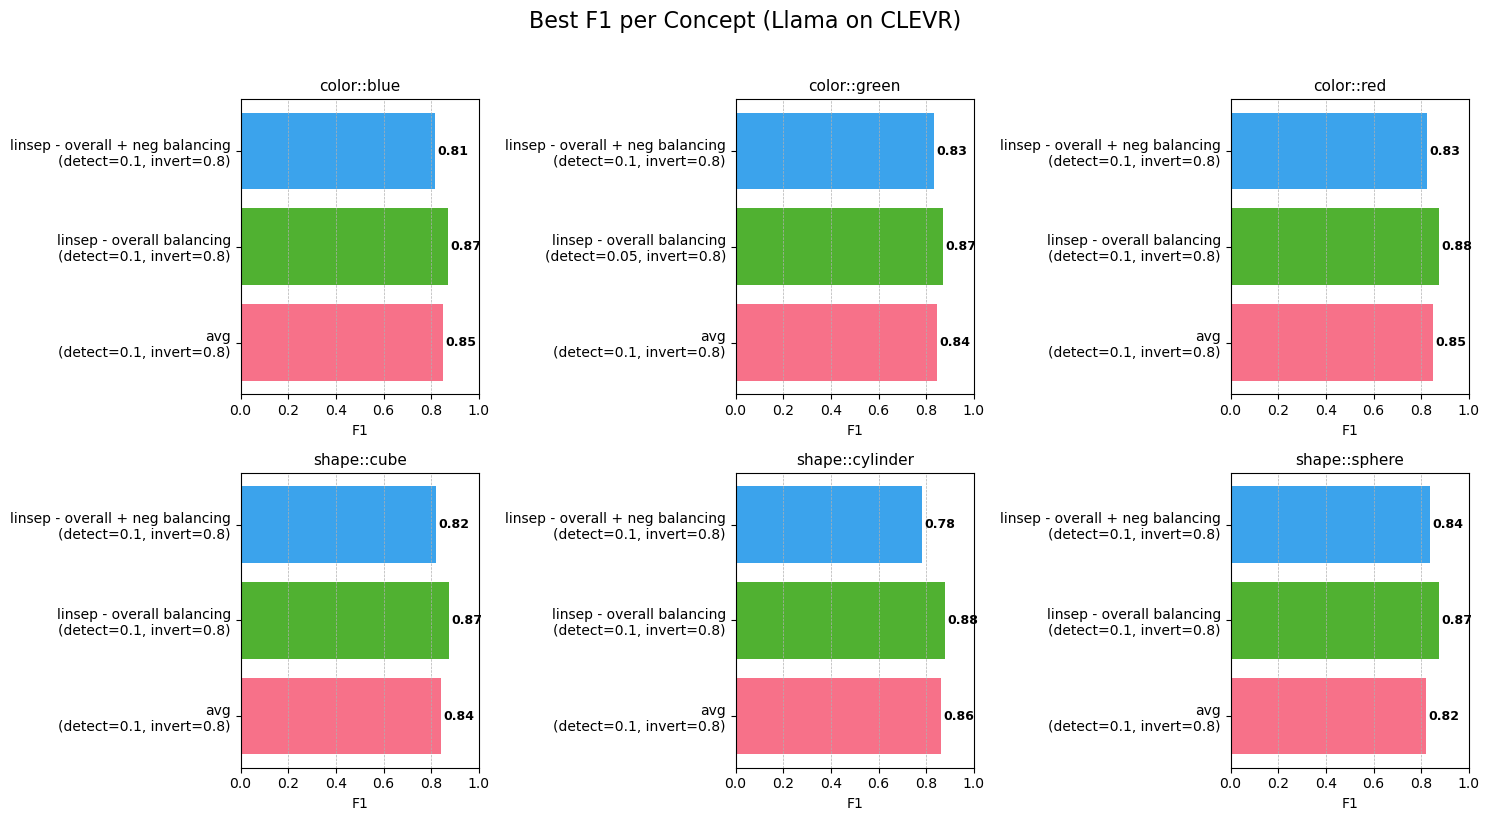

In [43]:
compare_best_schemes_per_concept(
    metric_type='f1',
    concept_schemes=['avg', 'linsep', 'unsupervised kmeans', 'unsupervised kmeans linsep'],
    dataset_name='CLEVR',
    model_name='Llama',
    detect_percents=[0.02, 0.05, 0.1],
    invert_percents=[0.2, 0.4, 0.6, 0.8, 1.0],
    justobj=False,
    superdetector_inversion=False,
    xmin=0.0,
    xmax=1.0
)

# Precision/Recall Curves

In [30]:
from sklearn.metrics import auc


def get_style_label_color(key, pr_auc):
    style_map = {
    'avg': {'color': 'orchid', 'type': 'supervised', 'label': 'patch avg'},
    'linsep': {'color': 'indigo', 'type': 'supervised', 'label': 'patch linsep'},
    'labeled cls avg': {'color': 'goldenrod', 'type': 'supervised', 'label': 'cls avg'},
    'labeled cls linsep': {'color': 'orangered', 'type': 'supervised', 'label': 'cls linsep'},
    'unsupervised patch kmeans': {'color': 'orchid', 'type': 'unsupervised', 'label': 'patch avg'},
    'unsupervised patch linsep kmeans': {'color': 'indigo', 'type': 'unsupervised', 'label': 'patch linsep'},
    'unsupervised cls kmeans': {'color': 'goldenrod', 'type': 'unsupervised', 'label': 'cls avg'},
    'unsupervised cls linsep kmeans': {'color': 'orangered', 'type': 'unsupervised', 'label': 'cls linsep'},
    }
    style = style_map.get(key, {})
    color = style.get('color', 'gray')
    label = f"{style.get('label', key)} (AUC={pr_auc:.2f})"
    return label, color
      
def plot_pr_curves_across_methods(
    dataset_name,
    split,
    model_name,
    sample_types,
    save_path=None,
    weighted=False,
    ax=None,
    style_map=None,
):

    percentiles = [0.02, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]
    con_labels = {}

    for sample_type in sample_types:
        n_clusters = 1000 if sample_type == "patch" else 50
        con_labels[f"labeled {sample_type} avg"] = f"{model_name}_avg_{sample_type}_embeddings_percentthrumodel_100"
        con_labels[f"labeled {sample_type} linsep"] = f"{model_name}_linsep_{sample_type}_embeddings_BD_True_BN_False_percentthrumodel_100"

    if dataset_name == 'Stanford-Tree-Bank':
        gt_path = f"GT_Samples/{dataset_name}/gt_samples_per_concept_{split}_inputsize_('text', 'text').pt"
    elif model_name == 'ClIP':
        gt_path = f"GT_Samples/{dataset_name}/gt_samples_per_concept_{split}_inputsize_(224, 224).pt"
    elif model_name == 'Llama':
        gt_path = f'GT_Samples/{dataset_name}/gt_samples_per_concept_{split}_inputsize_(560, 560).pt' 
    gt_concepts = torch.load(gt_path, weights_only=False)

    if weighted:
        if ax is None:
            fig, ax = plt.subplots(figsize=(7, 6))

        for method_name, con_label in con_labels.items():
            weighted_prec, weighted_rec = [0.0] * len(percentiles), [0.0] * len(percentiles)
            total_weight = 0.0

            for concept, gt_idxs in gt_concepts.items():
                weight = len(gt_idxs)
                prec, rec = [], []
                for p in percentiles:
                    file_name = f"Quant_Results/{dataset_name}/detectionmetrics_per_{p}_{con_label}.pt"
                    if not os.path.exists(file_name):
                        continue
                    df = torch.load(file_name, weights_only=False)
                    row = df[df["concept"] == concept]
                    if row.empty:
                        continue
                    prec.append(row["precision"].iloc[0])
                    rec.append(row["recall"].iloc[0])

                if len(prec) == len(percentiles):
                    weighted_prec = [wp + pr * weight for wp, pr in zip(weighted_prec, prec)]
                    weighted_rec = [wr + rc * weight for wr, rc in zip(weighted_rec, rec)]
                    total_weight += weight

            if total_weight == 0:
                continue

            avg_prec = [wp / total_weight for wp in weighted_prec]
            avg_rec = [wr / total_weight for wr in weighted_rec]
            pr_auc = auc(avg_rec, avg_prec)
            best_idx = max(range(len(avg_prec)), key=lambda i: (2 * avg_prec[i] * avg_rec[i]) / (avg_prec[i] + avg_rec[i] + 1e-8))
            best_f1 = (2 * avg_prec[best_idx] * avg_rec[best_idx]) / (avg_prec[best_idx] + avg_rec[best_idx] + 1e-8)
            
            label, color = get_style_label_color(method_name, pr_auc)
            plt.plot(avg_rec, avg_prec, label=label, color=color)
            plt.plot([avg_rec[best_idx]], [avg_prec[best_idx]], marker = 'o', color=color)
            plt.plot([0, avg_rec[best_idx]], [avg_prec[best_idx]] * 2, linestyle='--', color=color, alpha=0.6)
            plt.plot([avg_rec[best_idx]] * 2, [0, avg_prec[best_idx]], linestyle='--', color=color, alpha=0.6)
            plt.text(avg_rec[best_idx], avg_prec[best_idx], f"Best F1={best_f1:.2f}", fontsize=10, color=color)

        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.grid(True, which='both', linestyle='--', linewidth=0.5)
        plt.legend(title='Concept Type', loc="best")
        plt.xlim([0, 1.05])
        plt.ylim([0, 1.05])
        if save_path:
            os.makedirs(save_path, exist_ok=True)
            plt.savefig(os.path.join(save_path, "pr_weighted_all_methods.png"), dpi=300)
        plt.show()


def plot_pr_curves_patch_level(
    dataset_name,
    split,
    model_name,
    concept_schemes,
    percentiles,
    justobj=False,
    weighted=False,
    save_path=None,
    style_map=None
):

    base_dir = f"Quant_Results/{dataset_name}"
    if dataset_name == 'Stanford-Tree-Bank':
        gt_path = f"GT_Samples/{dataset_name}/gt_patch_per_concept_{split}_inputsize_('text', 'text').pt"
    elif model_name == 'CLIP':
        gt_path = f"GT_Samples/{dataset_name}/gt_patch_per_concept_{split}_inputsize_(224, 224).pt"
    elif model_name == 'Llama':
        gt_path = f'GT_Samples/{dataset_name}/gt_patch_per_concept_{split}_inputsize_(560, 560).pt' 
        
    gt_samples = torch.load(gt_path, weights_only=False)


    scheme_to_label = {
        'avg': '_avg_patch_embeddings_percentthrumodel_100.pt',
        'linsep': '_linsep_patch_embeddings_BD_True_BN_False_percentthrumodel_100.pt',
        'unsupervised kmeans': '_kmeans_1000_patch_embeddings_kmeans_percentthrumodel_100.pt',
        'unsupervised kmeans linsep': '_kmeans_1000_linsep_patch_embeddings_kmeans_percentthrumodel_100.pt',
    }

    if weighted:
        plt.figure(figsize=(8, 6))
        for scheme in concept_schemes:
            weighted_prec, weighted_rec = [0.0]*len(percentiles), [0.0]*len(percentiles)
            total_w = 0.0

            for concept, idxs in gt_samples.items():
                w = len(idxs)
                precs, recs = [], []
                for p in percentiles:
                    fp = f"Quant_Results/{dataset_name}/detectionmetrics_per_{p}_{model_name}{scheme_to_label[scheme]}"
                    if not os.path.exists(fp):
                        print(fp, "doesn't exist")
                        break
                    df = torch.load(fp, weights_only=False)
                    if 'kmeans' in scheme:
                        con_label = f'{model_name}_kmeans_1000{"_linsep" if "linsep" in scheme else ""}_patch_embeddings_kmeans_percentthrumodel_100'
                        align_path = f'Unsupervised_Matches/{dataset_name}/bestdetects_{con_label}.pt'
                        align_results = torch.load(align_path, weights_only=False)
                        cluster_to_concept = {str(info['best_cluster']): concept for concept, info in align_results.items()}
                        df = df.copy()
                        df['concept'] = df['concept'].astype(str).map(cluster_to_concept)

                    row = df[df['concept'] == concept]
                    if row.empty:
                        break
                    precs.append(row['precision'].iloc[0])
                    recs.append(row['recall'].iloc[0])
                else:
                    total_w += w
                    for i in range(len(percentiles)):
                        weighted_prec[i] += precs[i] * w
                        weighted_rec[i] += recs[i] * w

            if total_w > 0:
                avg_prec = [wp / total_w for wp in weighted_prec]
                avg_rec = [wr / total_w for wr in weighted_rec]
                pr_auc = auc(avg_rec, avg_prec)
                best_idx = max(range(len(avg_prec)), key=lambda i: (2 * avg_prec[i] * avg_rec[i]) / (avg_prec[i] + avg_rec[i] + 1e-8))
                best_f1 = (2 * avg_prec[best_idx] * avg_rec[best_idx]) / (avg_prec[best_idx] + avg_rec[best_idx] + 1e-8)

                label, color = get_style_label_color(scheme, pr_auc)
                plt.plot(avg_rec, avg_prec, label=label, color=color)
                plt.plot([avg_rec[best_idx]], [avg_prec[best_idx]], marker = 'o', color=color)
                plt.plot([0, avg_rec[best_idx]], [avg_prec[best_idx]] * 2, linestyle='--', color=color, alpha=0.6)
                plt.plot([avg_rec[best_idx]] * 2, [0, avg_prec[best_idx]], linestyle='--', color=color, alpha=0.6)
                plt.text(avg_rec[best_idx], avg_prec[best_idx], f"Best F1={best_f1:.2f}", fontsize=10, color=color)

        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.grid(True, which='both', linestyle='--', linewidth=0.5)
        plt.legend(title='Concept Type', loc='best')
        plt.xlim([0, 1.05])
        plt.ylim([0, 1.05])
        if save_path:
            os.makedirs(save_path, exist_ok=True)
            plt.savefig(os.path.join(save_path, "pr_weighted_patch_level.png"), dpi=300)
        plt.show()

## For CLS token Level

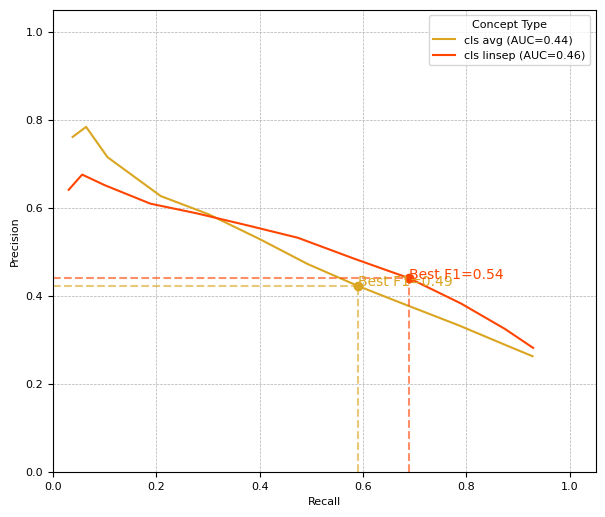

In [40]:
plot_pr_curves_across_methods(dataset_name='Coco', 
                               split='test', 
                               model_name='Llama', 
                               sample_types=['cls'], 
                               save_path=None,
                              weighted=True)

## For Patch Level

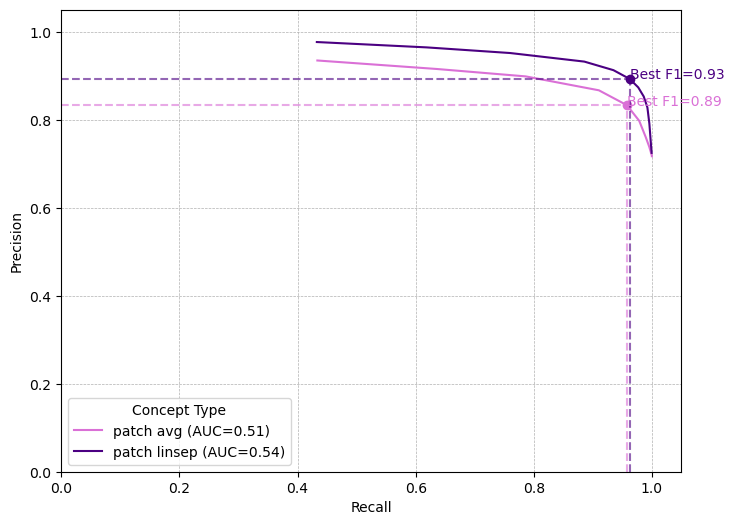

In [48]:
plot_pr_curves_patch_level(
    dataset_name='Broden-Pascal',
    split='test',
    model_name='CLIP',
    concept_schemes=["avg","linsep"],
    percentiles=[0.02,0.05,0.1,0.2,0.3, 0.4, 0.5,0.6,0.7,0.8,0.9,0.95, 0.95],
    justobj=False,
    weighted=True,
    save_path=None
)